# Two-Stage Experiment — Exploratory Data Analysis

CSV: `experiment__w0_1000000__n3__baseline_mixed_even_full.csv`

Two diversification weights: **w=0** (cost-only) and **w=1,000,000** (resilience-priority).
Four Stage-2 packing configs: `baseline / mixed / even / full`.
Six instance sizes: `paper, small, medium, large, xlarge, industrylite`.

Section A ports the visualisations from the legacy `plot_*` scripts.
Section B adds new diagnostic plots worth inspecting before the next sweep.
Section C cross-compares the two-stage results against the one-shot benchmark.


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (10, 5),
})

CSV = "experiment__w0_1000000__n3__baseline_mixed_even_full.csv"

SIZE_ORDER   = ["paper", "small", "medium", "large", "xlarge", "industrylite"]
CONFIG_ORDER = ["baseline", "mixed", "even", "full"]
CONFIG_COLOR = {"baseline": "#bdbdbd", "mixed": "#74c0fc",
                "even":     "#ffa94d", "full":  "#69db7c"}
SIZE_COLOR   = {"paper": "#2ca02c", "small": "#1f77b4", "medium": "#ff7f0e",
                "large": "#d62728", "xlarge": "#9467bd", "industrylite": "#8c564b"}
SIZE_MARKER  = {"paper": "o", "small": "s", "medium": "^",
                "large": "D", "xlarge": "P", "industrylite": "X"}
ALPHAS = [0.2, 0.4, 0.6, 0.8]


In [3]:
df = pd.read_csv(CSV)
df = df[df["status"] == "OK"].copy()

# Categorical ordering
df["instance_size"] = pd.Categorical(df["instance_size"], categories=SIZE_ORDER, ordered=True)
df["s2_config"]     = pd.Categorical(df["s2_config"],     categories=CONFIG_ORDER, ordered=True)

# Convenience derived columns
df["total_time"] = df["s1_time"] + df["s2_time"]
df["cost_saving_pct"] = np.where(
    df["s1_dispatch_cost"] > 0,
    df["cost_saving"] / df["s1_dispatch_cost"] * 100,
    np.nan,
)

print(f"{len(df)} rows  |  {df['instance_name'].nunique()} instances  "
      f"|  weights={sorted(df['weight'].unique())}  |  seeds={sorted(df['seed'].unique())}")
df.head(3)


200 rows  |  25 instances  |  weights=[np.int64(0), np.int64(1000000)]  |  seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,instance_name,instance_type,instance_size,seed,n_locations,n_parts,n_routes,n_transports,density,capacity_tightness,...,first_r_heaviest_single_0.4,first_r_heaviest_single_0.6,first_r_heaviest_single_0.8,first_r_heaviest_global_0.2,first_r_heaviest_global_0.4,first_r_heaviest_global_0.6,first_r_heaviest_global_0.8,status,total_time,cost_saving_pct
0,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK,660.339,26.857054
1,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK,660.347,26.857054
2,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OK,660.346,17.909127


## 1. Experiment Grid Overview

Coverage matrix: rows × (size, weight, s2_config). Confirms the sweep is balanced
before drawing any aggregate conclusion.

In [4]:
grid = (df.groupby(["instance_size", "weight", "s2_config"], observed=True)
          .size()
          .unstack("s2_config", fill_value=0))
grid


s2_config              baseline  mixed  even  full
instance_size weight                              
paper         0               1      1     1     1
              1000000         1      1     1     1
small         0               5      5     5     5
              1000000         5      5     5     5
medium        0               5      5     5     5
              1000000         5      5     5     5
large         0               5      5     5     5
              1000000         5      5     5     5
xlarge        0               5      5     5     5
              1000000         5      5     5     5
industrylite  0               4      4     4     4
              1000000         4      4     4     4

In [5]:
# Optimality picture — how many runs proved optimal within the size's time limit
opt = (df.groupby(["instance_size", "weight"], observed=True)
         .agg(s1_opt_rate=("s1_optimal", "mean"),
              s2_opt_rate=("s2_optimal", "mean"),
              s1_time=("s1_time", "mean"),
              s2_time=("s2_time", "mean"),
              n=("s1_optimal", "size"))
         .round(3))
opt


s1_opt_rate  s2_opt_rate  s1_time  s2_time   n
instance_size weight                                                 
paper         0                1.0         0.50   12.329  300.095   4
              1000000          1.0         1.00    4.331    0.121   4
small         0                0.6         0.40   33.375  364.374  20
              1000000          0.2         0.65  481.203  228.578  20
medium        0                0.0         0.35   72.081  398.176  20
              1000000          0.0         0.60  204.133  252.269  20
large         0                0.0         0.00  108.076  600.017  20
              1000000          0.0         0.10   90.059  568.688  20
xlarge        0                0.0         0.00   96.151  600.025  20
              1000000          0.0         0.00   72.106  600.025  20
industrylite  0                0.0         0.00   90.268  600.030  16
              1000000          0.0         0.00  135.314  600.032  16

---
## Section A — Ported visualisations from `src/experiments/two_stage/final/plot_*`

Same questions, refreshed on the new CSV schema.


### A1. R_TR vs Stage 1 weight (per size, mean ± std)

`R_TR` only depends on Stage 1, so we average over s2_config. The fan opens up as
`w` grows: bigger instances start lower and have more room to improve.

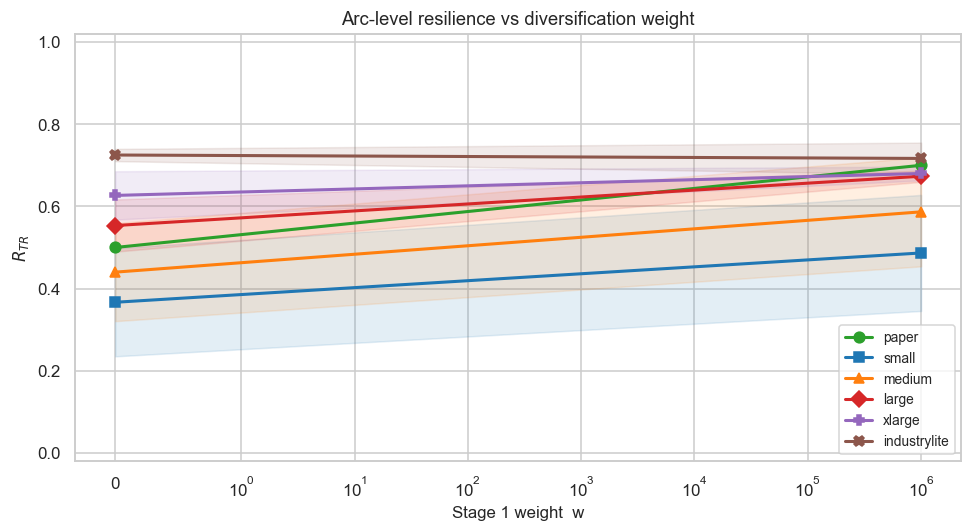

In [6]:
def plot_rtr_vs_weight(df):
    sub = df.copy()
    fig, ax = plt.subplots(figsize=(9, 5))
    for size in SIZE_ORDER:
        s = sub[sub["instance_size"] == size]
        if s.empty:
            continue
        g = s.groupby("weight")["r_tr"].agg(["mean", "std"]).reset_index().sort_values("weight")
        ax.plot(g["weight"], g["mean"], marker=SIZE_MARKER[size],
                color=SIZE_COLOR[size], linewidth=2, markersize=7, label=size)
        ax.fill_between(g["weight"],
                        g["mean"] - g["std"].fillna(0),
                        g["mean"] + g["std"].fillna(0),
                        color=SIZE_COLOR[size], alpha=0.12)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("Stage 1 weight  w")
    ax.set_ylabel(r"$R_{TR}$")
    ax.set_title("Arc-level resilience vs diversification weight")
    ax.set_ylim(-0.02, 1.02)
    ax.legend()
    fig.tight_layout(); plt.show()

plot_rtr_vs_weight(df)


### A2. R_1 by Stage 2 config × weight (grouped bars, per size)

Stage-2 packing constraints (`mixed / even / full`) should lift `R_1` above the
`baseline` packing — especially once Stage 1 has diversified arc usage (w>0).

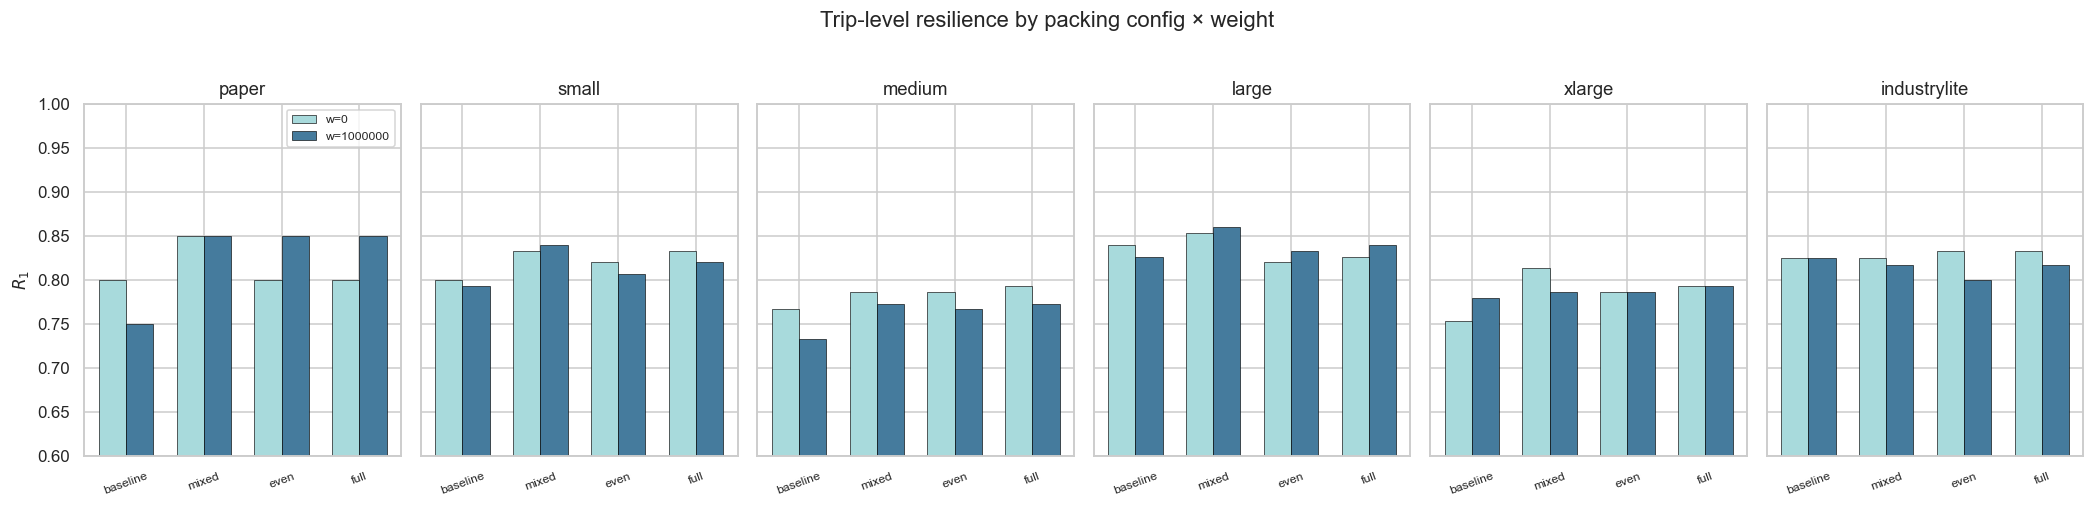

In [7]:
def plot_r1_by_config(df):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    n = len(sizes)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4.5), sharey=True)
    if n == 1:
        axes = [axes]
    weights = sorted(df["weight"].unique())
    width = 0.35
    for ax, size in zip(axes, sizes):
        s = df[df["instance_size"] == size]
        x = np.arange(len(CONFIG_ORDER))
        for i, w in enumerate(weights):
            vals = [s[(s["weight"] == w) & (s["s2_config"] == c)]["r_1"].mean()
                    for c in CONFIG_ORDER]
            offset = (i - (len(weights) - 1) / 2) * width
            ax.bar(x + offset, vals, width, label=f"w={w}",
                   edgecolor="black", linewidth=0.4,
                   color=("#a8dadc" if i == 0 else "#457b9d"))
        ax.set_xticks(x)
        ax.set_xticklabels(CONFIG_ORDER, fontsize=8, rotation=20)
        ax.set_title(size)
        ax.set_ylim(0.6, 1.0)
        if ax is axes[0]:
            ax.set_ylabel(r"$R_1$")
            ax.legend(fontsize=8)
    fig.suptitle("Trip-level resilience by packing config × weight", y=1.02)
    fig.tight_layout(); plt.show()

plot_r1_by_config(df)


### A3. R_α degradation curves (heaviest strategy, single & global)

How fast does coverage decay as the disruption survival fraction α drops?
One panel per size, lines per Stage-2 config, evaluated at the high weight.

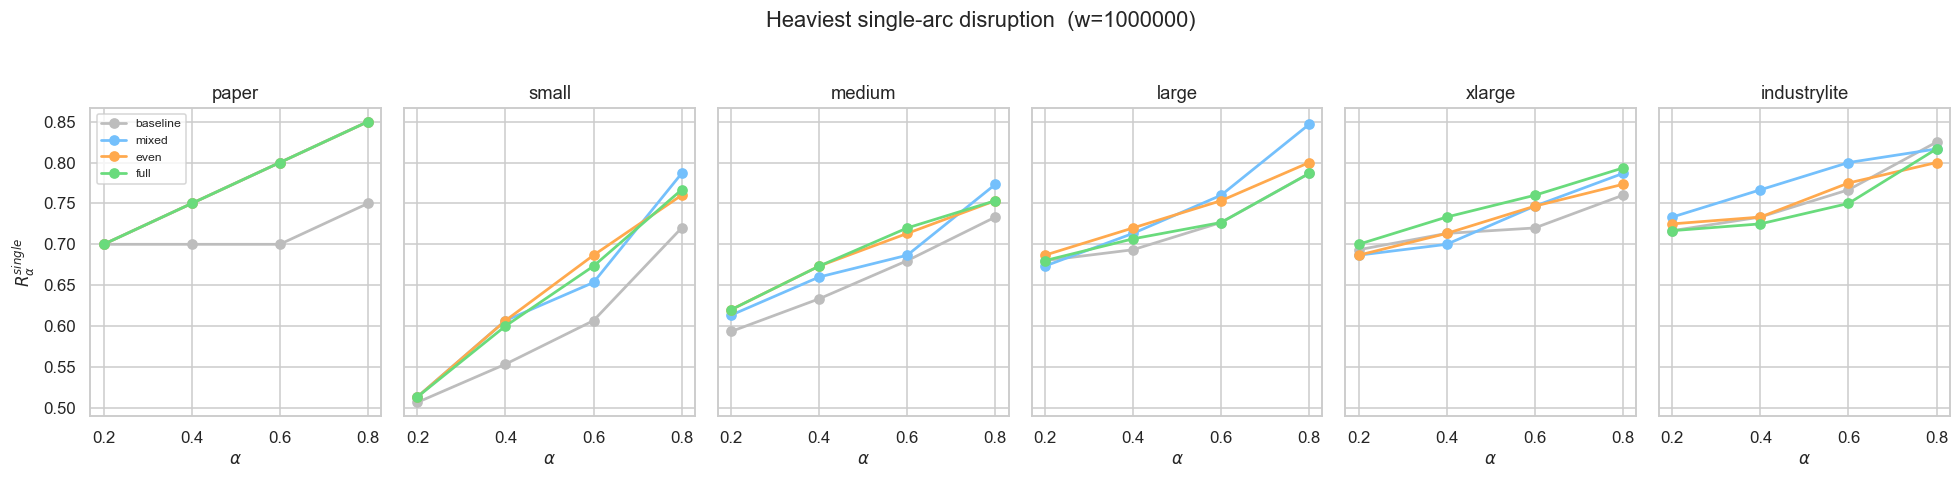

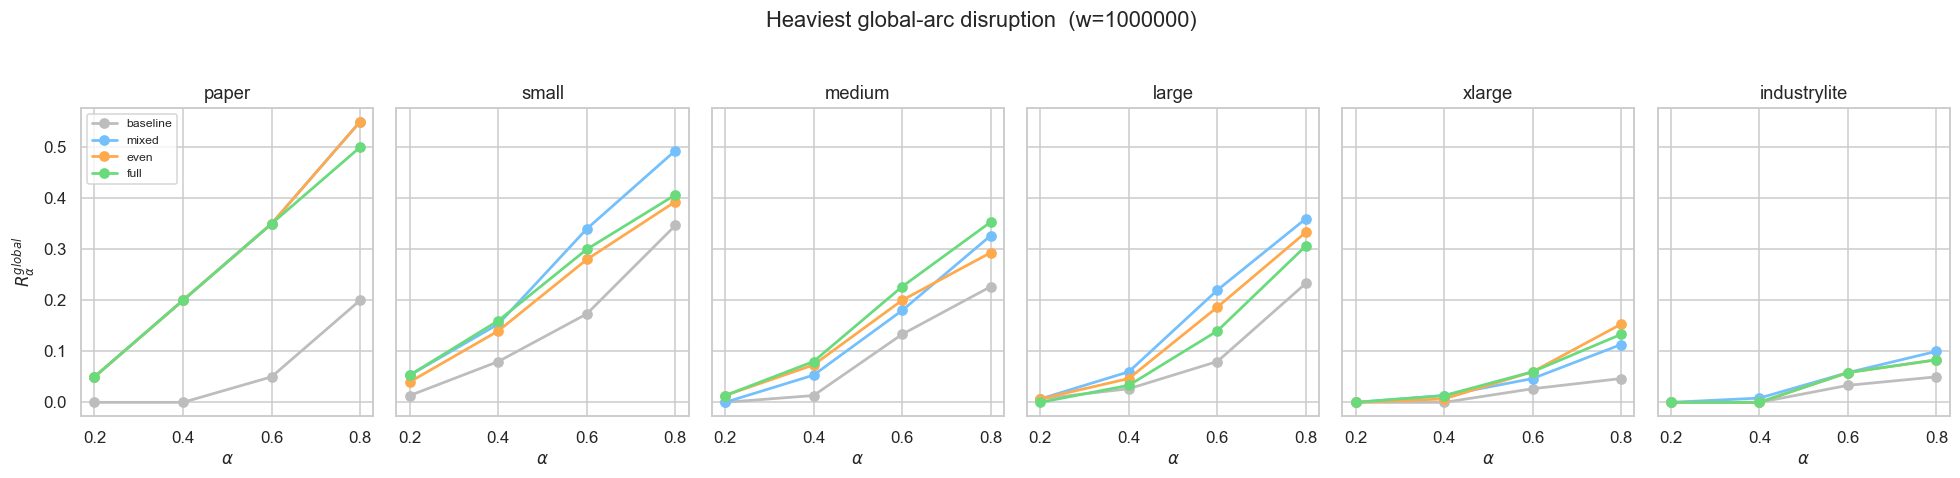

In [8]:
def plot_ralpha_curves(df, weight=None, mode="single"):
    if weight is None:
        weight = df["weight"].max()
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    n = len(sizes)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4.2), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, size in zip(axes, sizes):
        s = df[(df["instance_size"] == size) & (df["weight"] == weight)]
        for cfg in CONFIG_ORDER:
            cs = s[s["s2_config"] == cfg]
            if cs.empty:
                continue
            ys = [cs[f"r_heaviest_{mode}_{a}"].mean() for a in ALPHAS]
            ax.plot(ALPHAS, ys, marker="o", linewidth=1.8,
                    color=CONFIG_COLOR[cfg], label=cfg)
        ax.set_xticks(ALPHAS)
        ax.set_title(f"{size}")
        ax.set_xlabel(r"$\alpha$")
        if ax is axes[0]:
            ax.set_ylabel(fr"$R_\alpha^{{{mode}}}$")
            ax.legend(fontsize=8)
    fig.suptitle(fr"Heaviest {mode}-arc disruption  (w={weight})", y=1.03)
    fig.tight_layout(); plt.show()

plot_ralpha_curves(df, mode="single")
plot_ralpha_curves(df, mode="global")


### A4. R_α heatmap — size × α at the high weight

Compresses the four α-curves into one tile per (size, α). Uses `mixed` config
to isolate the packing effect; values close to 1 are best.

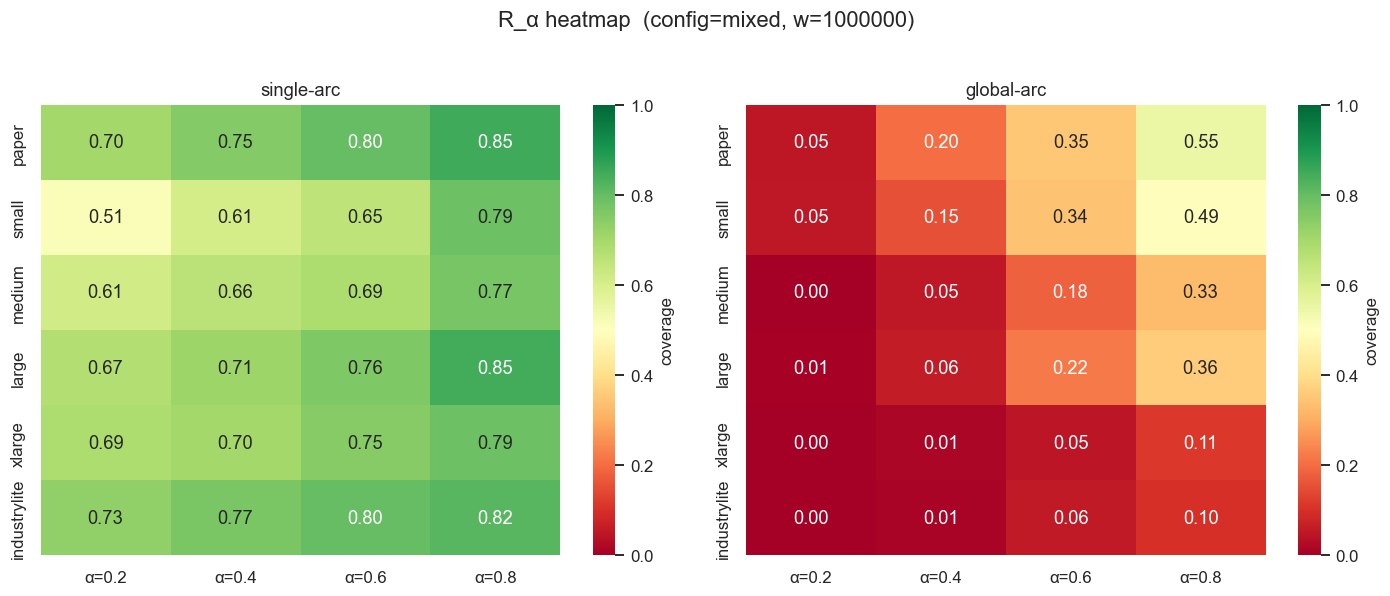

In [9]:
def plot_ralpha_heatmap(df, weight=None, config="mixed"):
    if weight is None:
        weight = df["weight"].max()
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    fig, axes = plt.subplots(1, 2, figsize=(13, 0.55 * len(sizes) + 2))
    for ax, mode in zip(axes, ["single", "global"]):
        mat = []
        for size in sizes:
            s = df[(df["instance_size"] == size)
                   & (df["weight"] == weight)
                   & (df["s2_config"] == config)]
            mat.append([s[f"r_heaviest_{mode}_{a}"].mean() for a in ALPHAS])
        mat = np.array(mat)
        sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn",
                    vmin=0, vmax=1, ax=ax,
                    xticklabels=[f"α={a}" for a in ALPHAS],
                    yticklabels=sizes,
                    cbar_kws={"label": "coverage"})
        ax.set_title(f"{mode}-arc")
    fig.suptitle(f"R_α heatmap  (config={config}, w={weight})", y=1.02)
    fig.tight_layout(); plt.show()

plot_ralpha_heatmap(df)


### A5. R_1 vs R_TR scatter

Each point = one run. Above the diagonal means Stage-2 packing improved
trip-coverage beyond arc-coverage — which is the headline claim of the
two-stage decomposition.

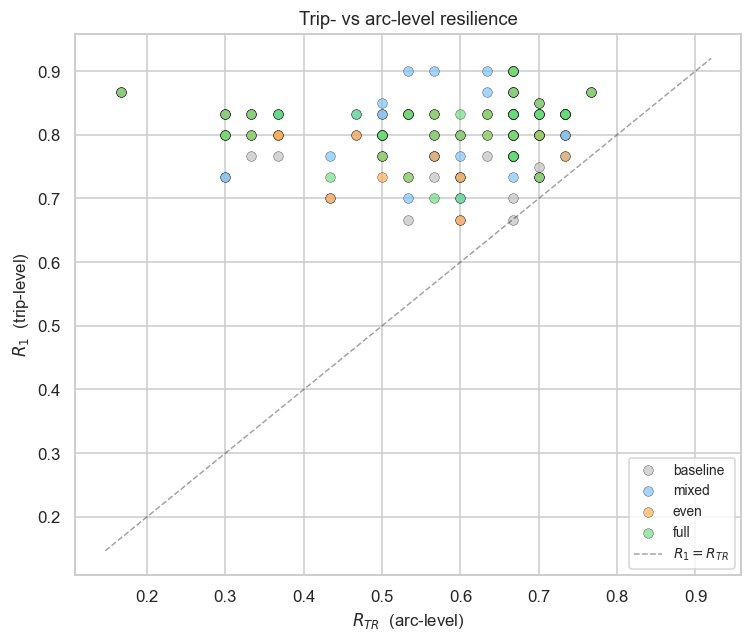

In [10]:
def plot_r1_vs_rtr(df):
    fig, ax = plt.subplots(figsize=(7, 6))
    for cfg in CONFIG_ORDER:
        s = df[df["s2_config"] == cfg]
        ax.scatter(s["r_tr"], s["r_1"], s=40, alpha=0.65,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.3,
                   label=cfg)
    lo = min(df["r_tr"].min(), df["r_1"].min()) - 0.02
    hi = max(df["r_tr"].max(), df["r_1"].max()) + 0.02
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, linewidth=1, label=r"$R_1 = R_{TR}$")
    ax.set_xlabel(r"$R_{TR}$  (arc-level)")
    ax.set_ylabel(r"$R_1$  (trip-level)")
    ax.set_title("Trip- vs arc-level resilience")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_r1_vs_rtr(df)


### A6. Cost ↔ R_TR Pareto with exposure colouring

The classic chart from `plot_paper_charts.plot_cost_vs_rtr_pareto`. Points coloured
by `exposure_count` (number of arcs carrying ≥ 1/N of total value). Pareto frontier
joins non-dominated points (low cost, high R_TR). Plotted per size, baseline config.

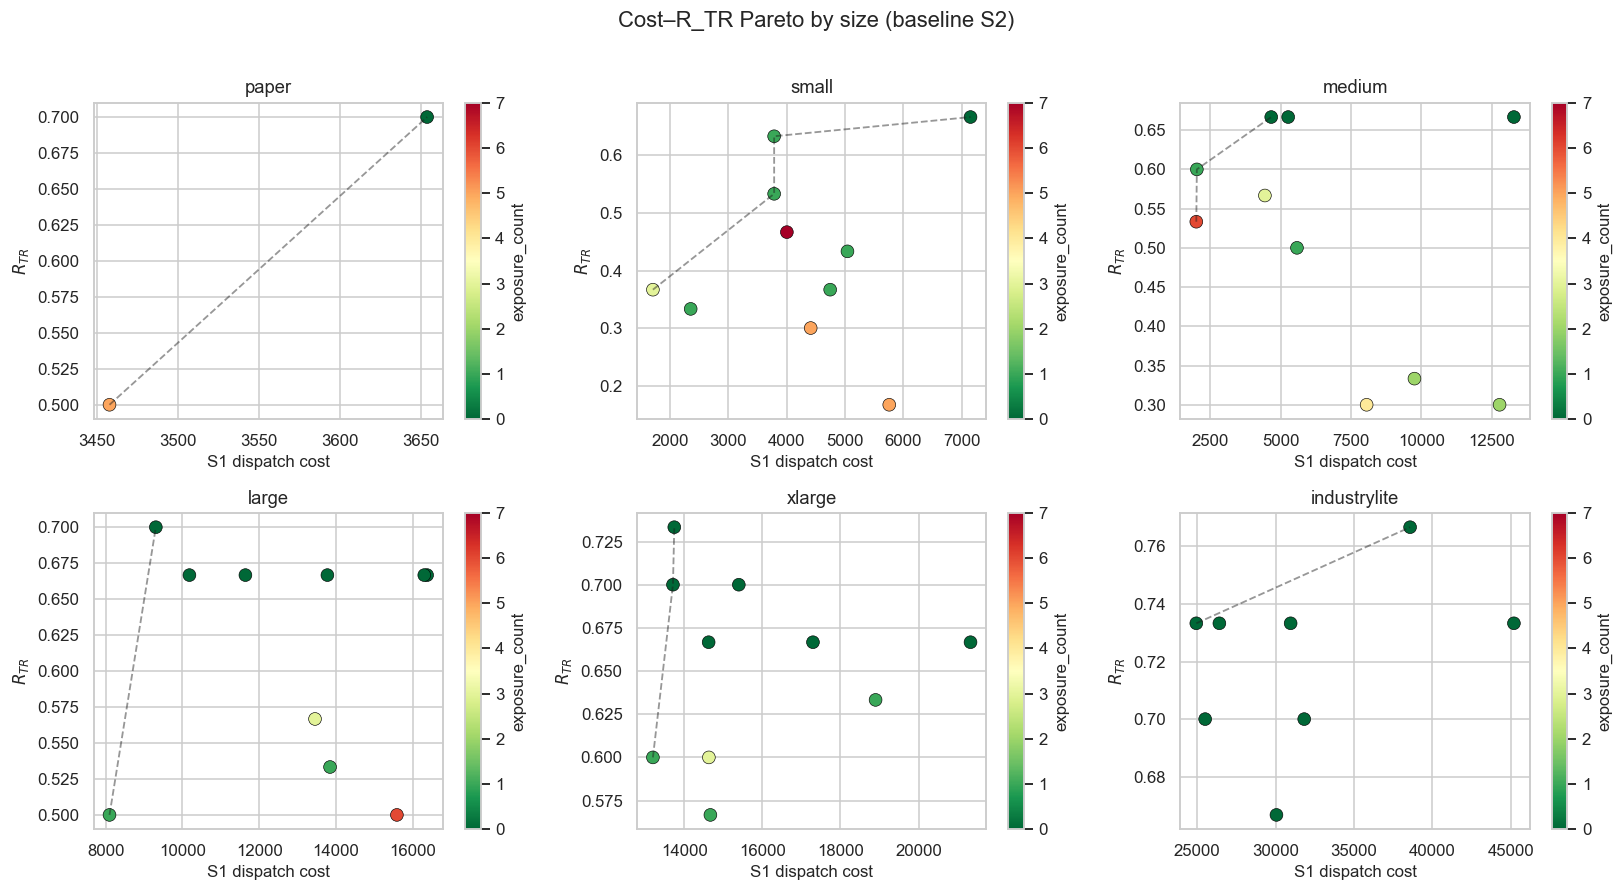

In [11]:
def plot_pareto_per_size(df):
    sub = df[df["s2_config"] == "baseline"].copy()
    sizes = [s for s in SIZE_ORDER if (sub["instance_size"] == s).any()]
    n = len(sizes)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    vmax = max(sub["exposure_count"].max(), 1)
    for ax, size in zip(axes.flat, sizes):
        s = sub[sub["instance_size"] == size]
        sc = ax.scatter(s["s1_dispatch_cost"], s["r_tr"],
                        c=s["exposure_count"], cmap="RdYlGn_r",
                        vmin=0, vmax=vmax, s=70, edgecolor="black", linewidth=0.4)
        # Pareto front: low cost, high r_tr
        front = []
        best = -1
        for _, r in s.sort_values("s1_dispatch_cost").iterrows():
            if r["r_tr"] > best:
                front.append(r); best = r["r_tr"]
        if len(front) > 1:
            ax.plot([r["s1_dispatch_cost"] for r in front],
                    [r["r_tr"] for r in front], "k--", alpha=0.45, linewidth=1.2)
        ax.set_xlabel("S1 dispatch cost")
        ax.set_ylabel(r"$R_{TR}$")
        ax.set_title(size)
        fig.colorbar(sc, ax=ax, label="exposure_count")
    # hide unused axes
    for ax in axes.flat[len(sizes):]:
        ax.set_visible(False)
    fig.suptitle("Cost–R_TR Pareto by size (baseline S2)", y=1.01)
    fig.tight_layout(); plt.show()

plot_pareto_per_size(df)


### A7. S1 planned vs S2 actual dispatch cost

Stage 2 packs trips onto the routes Stage 1 chose; it can usually consolidate
load → fewer trips → lower dispatch cost. The −% annotation is the saving.

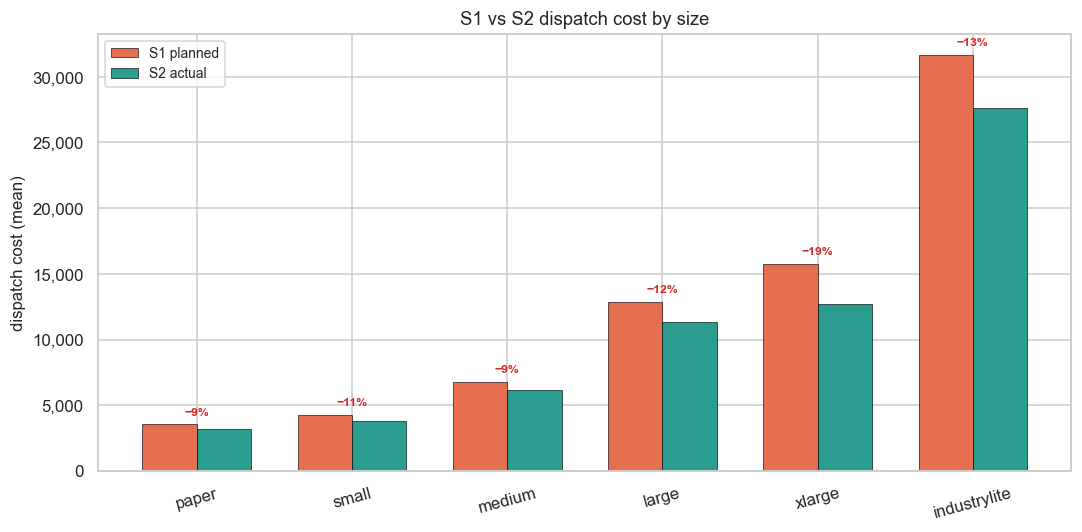

In [12]:
def plot_s1_vs_s2_cost(df):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    x = np.arange(len(sizes)); width = 0.35
    s1 = [df[df["instance_size"] == s]["s1_dispatch_cost"].mean() for s in sizes]
    s2 = [df[df["instance_size"] == s]["s2_dispatch_cost"].mean() for s in sizes]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, s1, width, label="S1 planned", color="#e76f51", edgecolor="black", linewidth=0.4)
    ax.bar(x + width / 2, s2, width, label="S2 actual",  color="#2a9d8f", edgecolor="black", linewidth=0.4)
    for i, (a, b) in enumerate(zip(s1, s2)):
        if a > 0:
            ax.annotate(f"−{(a - b) / a * 100:.0f}%", (x[i], max(a, b)),
                        textcoords="offset points", xytext=(0, 6),
                        ha="center", fontsize=8, color="#d62728", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(sizes, rotation=15)
    ax.set_ylabel("dispatch cost (mean)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_title("S1 vs S2 dispatch cost by size")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_s1_vs_s2_cost(df)


### A8. Soft-constraint ablation — mono / concentrated trip counts

Sanity check that turning `hetero_on` reduces mono-part trips and `concentrated_on`
reduces overloaded trips. Grouped by size, one bar per config.

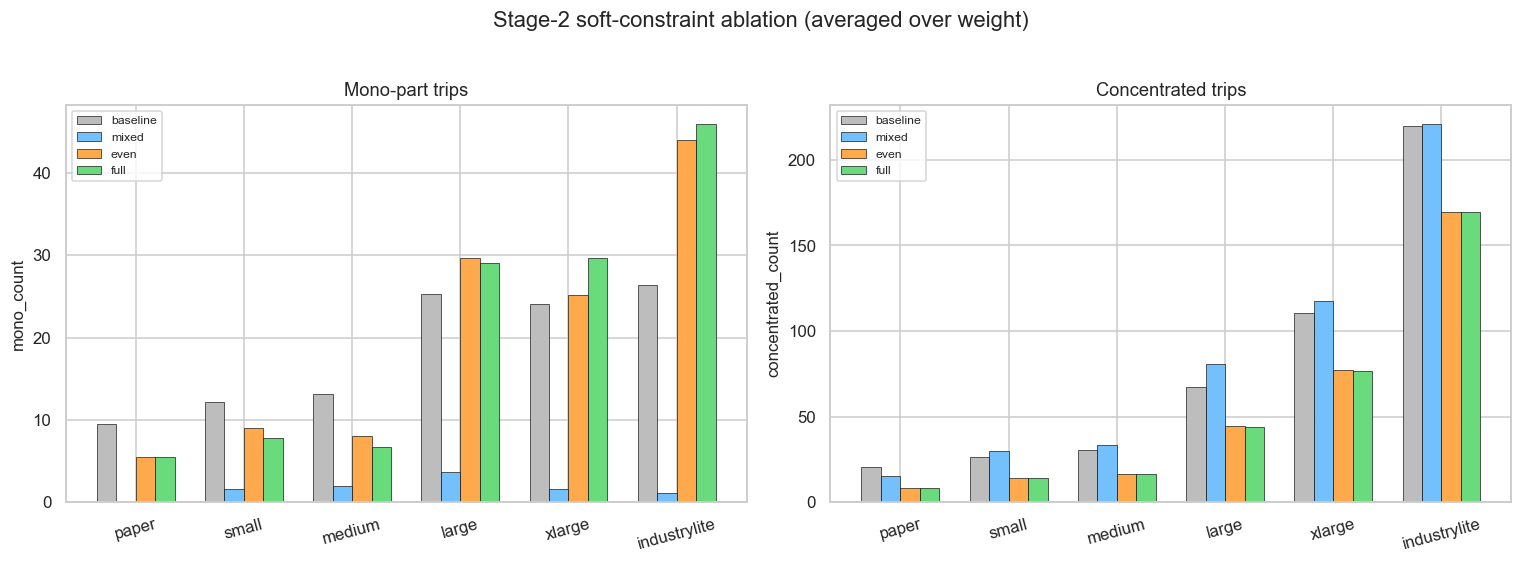

In [13]:
def plot_soft_constraint_counts(df):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in [(axes[0], "mono_count",        "Mono-part trips"),
                              (axes[1], "concentrated_count", "Concentrated trips")]:
        x = np.arange(len(sizes)); width = 0.18
        for i, cfg in enumerate(CONFIG_ORDER):
            vals = [df[(df["instance_size"] == s) & (df["s2_config"] == cfg)][metric].mean()
                    for s in sizes]
            ax.bar(x + (i - 1.5) * width, vals, width,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.4,
                   label=cfg)
        ax.set_xticks(x); ax.set_xticklabels(sizes, rotation=15)
        ax.set_ylabel(metric)
        ax.set_title(title)
        ax.legend(fontsize=8)
    fig.suptitle("Stage-2 soft-constraint ablation (averaged over weight)", y=1.02)
    fig.tight_layout(); plt.show()

plot_soft_constraint_counts(df)


### A9. Scalability — solve time + proven optimality by size

Twin-panel: average S1+S2 time and the share of runs that closed the gap.
Time limits are size-specific (paper 30s … industrylite 600s), so optimality
rate is more meaningful than raw time.

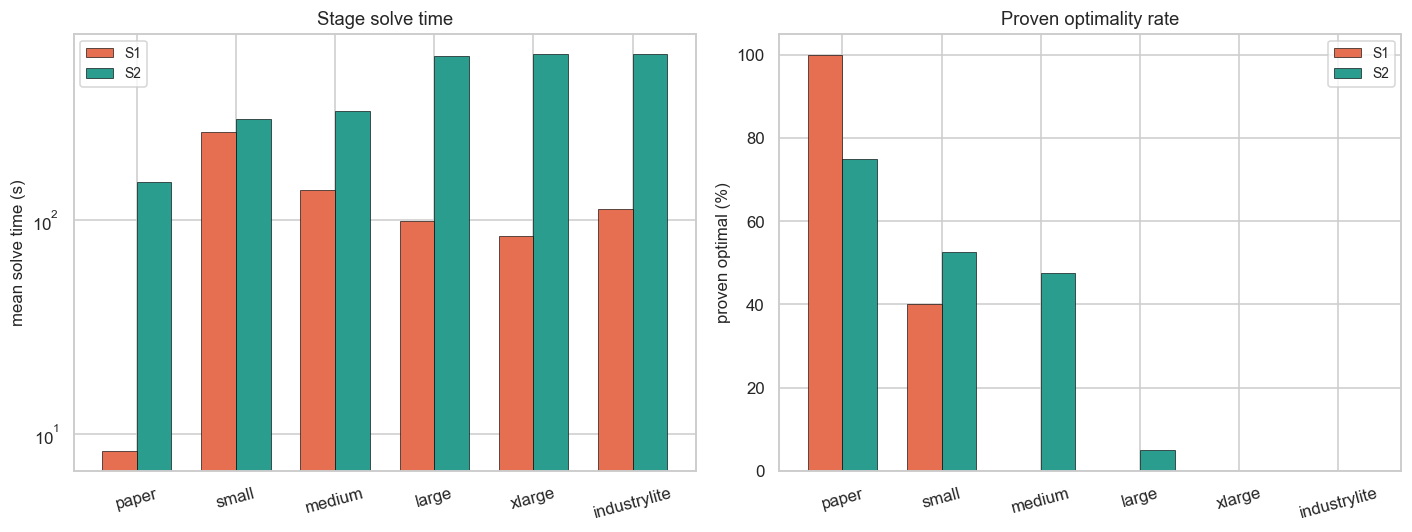

In [14]:
def plot_scalability(df):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(sizes)); width = 0.35
    s1t = [df[df["instance_size"] == s]["s1_time"].mean() for s in sizes]
    s2t = [df[df["instance_size"] == s]["s2_time"].mean() for s in sizes]
    axes[0].bar(x - width / 2, s1t, width, label="S1", color="#e76f51", edgecolor="black", linewidth=0.4)
    axes[0].bar(x + width / 2, s2t, width, label="S2", color="#2a9d8f", edgecolor="black", linewidth=0.4)
    axes[0].set_xticks(x); axes[0].set_xticklabels(sizes, rotation=15)
    axes[0].set_ylabel("mean solve time (s)")
    axes[0].set_title("Stage solve time")
    axes[0].set_yscale("log")
    axes[0].legend()

    s1o = [df[df["instance_size"] == s]["s1_optimal"].mean() * 100 for s in sizes]
    s2o = [df[df["instance_size"] == s]["s2_optimal"].mean() * 100 for s in sizes]
    axes[1].bar(x - width / 2, s1o, width, label="S1", color="#e76f51", edgecolor="black", linewidth=0.4)
    axes[1].bar(x + width / 2, s2o, width, label="S2", color="#2a9d8f", edgecolor="black", linewidth=0.4)
    axes[1].set_xticks(x); axes[1].set_xticklabels(sizes, rotation=15)
    axes[1].set_ylabel("proven optimal (%)")
    axes[1].set_ylim(0, 105)
    axes[1].set_title("Proven optimality rate")
    axes[1].legend()

    fig.tight_layout(); plt.show()

plot_scalability(df)


---
## Section B — New EDA worth exploring

Plots that the legacy scripts did not have but that the new schema enables.
Each cell ends with a short note on what to look for.


### B1. Exposure count: distribution + collapse with weight

`exposure_count` = number of arc-TRs carrying ≥ 1/N of total demand value
(the Stage-1 soft-constraint target). Boxplot per (size, weight) shows whether
the high weight is genuinely zeroing the count or just shaving it.

/var/folders/w3/gjrfn8hn0j9_rq65l7y8n9000000gn/T/ipykernel_41822/102194202.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="bucket", y="exposure_count", order=order, ax=ax,
/var/folders/w3/gjrfn8hn0j9_rq65l7y8n9000000gn/T/ipykernel_41822/102194202.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)


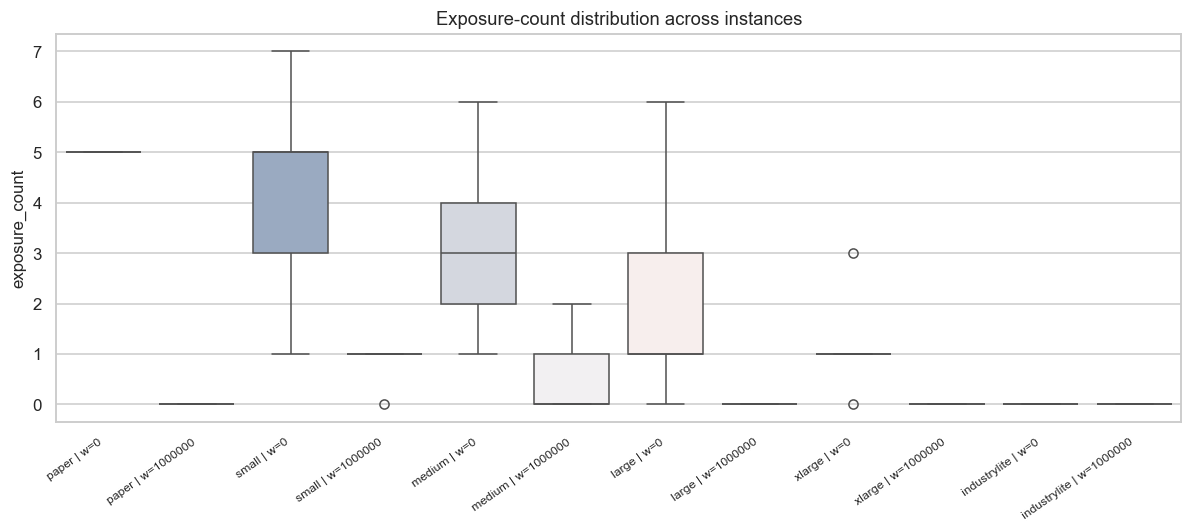

In [15]:
def plot_exposure_distribution(df):
    fig, ax = plt.subplots(figsize=(11, 5))
    sub = df[df["s2_config"] == "baseline"].copy()
    sub["bucket"] = sub["instance_size"].astype(str) + " | w=" + sub["weight"].astype(str)
    order = [f"{s} | w={w}" for s in SIZE_ORDER for w in sorted(sub["weight"].unique())
             if ((sub["instance_size"] == s) & (sub["weight"] == w)).any()]
    sns.boxplot(data=sub, x="bucket", y="exposure_count", order=order, ax=ax,
                palette="vlag")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("exposure_count")
    ax.set_title("Exposure-count distribution across instances")
    fig.tight_layout(); plt.show()

plot_exposure_distribution(df)


### B2. Seed-level variance: how stable is R_TR?

Per (size, weight, config) we have up to 5 seeds. A wide spread means the
encoding's behaviour depends heavily on instance layout — worth reporting.

/var/folders/w3/gjrfn8hn0j9_rq65l7y8n9000000gn/T/ipykernel_41822/2150250701.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df[df["s2_config"] == "mixed"],
/var/folders/w3/gjrfn8hn0j9_rq65l7y8n9000000gn/T/ipykernel_41822/2150250701.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df[df["s2_config"] == "mixed"],


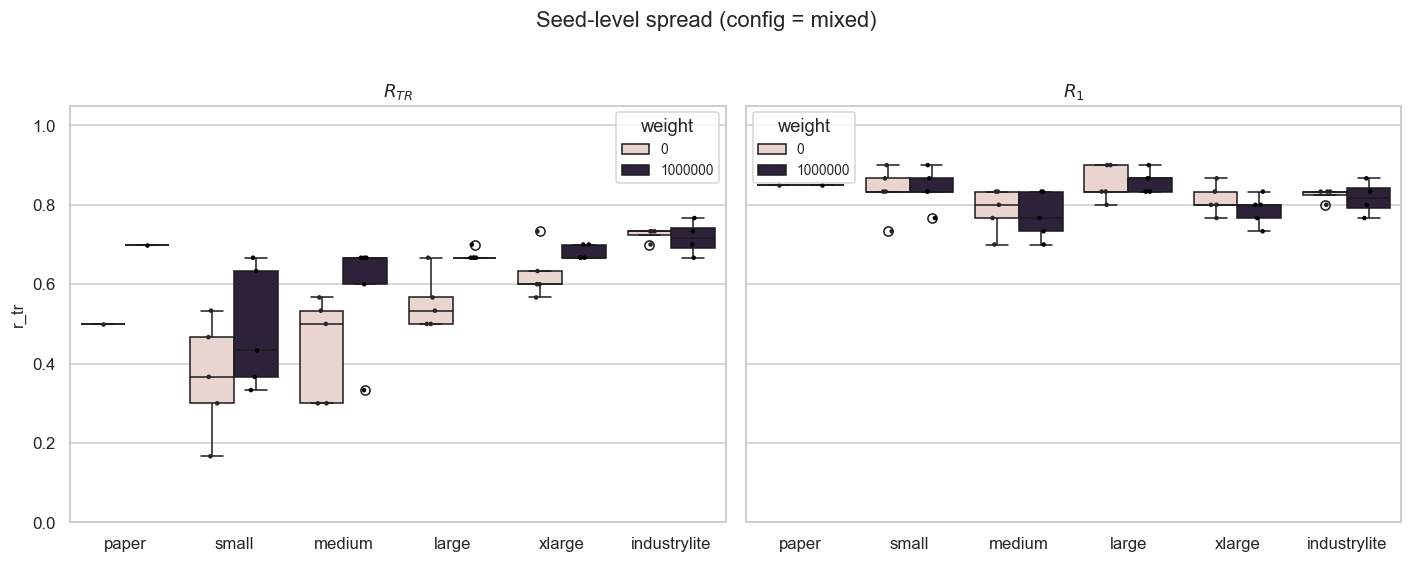

In [16]:
def plot_seed_variance(df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, metric, title in [(axes[0], "r_tr", r"$R_{TR}$"),
                              (axes[1], "r_1",  r"$R_1$")]:
        sns.boxplot(data=df[df["s2_config"] == "mixed"],
                    x="instance_size", y=metric,
                    hue="weight", order=SIZE_ORDER, ax=ax)
        sns.stripplot(data=df[df["s2_config"] == "mixed"],
                      x="instance_size", y=metric,
                      hue="weight", order=SIZE_ORDER,
                      dodge=True, ax=ax, color="black", size=3, legend=False)
        ax.set_title(title)
        ax.set_xlabel(""); ax.set_ylabel(metric)
        ax.set_ylim(0, 1.05)
    fig.suptitle("Seed-level spread (config = mixed)", y=1.02)
    fig.tight_layout(); plt.show()

plot_seed_variance(df)


### B3. Correlation matrix of resilience + cost + timing metrics

Quick Spearman heatmap — pick out the metrics that genuinely move together vs
those that look redundant. Useful for deciding which to report in the paper.

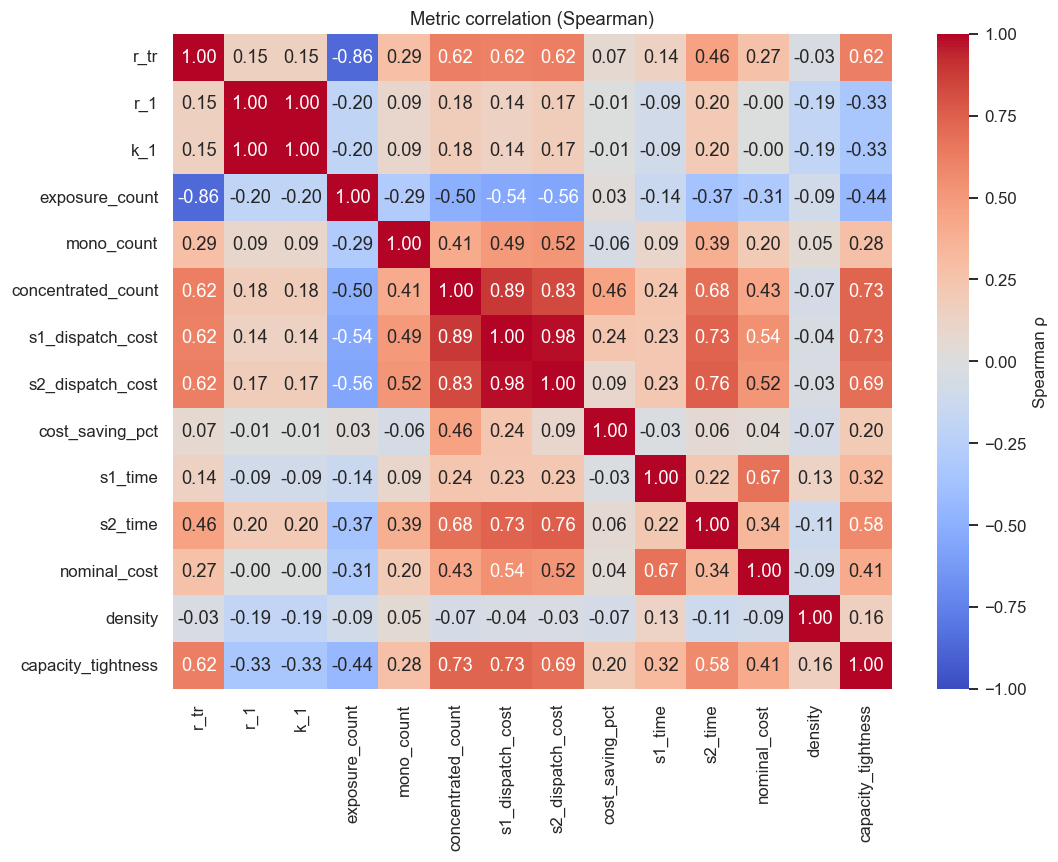

In [17]:
def plot_correlations(df):
    cols = ["r_tr", "r_1", "k_1",
            "exposure_count", "mono_count", "concentrated_count",
            "s1_dispatch_cost", "s2_dispatch_cost", "cost_saving_pct",
            "s1_time", "s2_time", "nominal_cost",
            "density", "capacity_tightness"]
    cols = [c for c in cols if c in df.columns]
    corr = df[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, ax=ax,
                cbar_kws={"label": "Spearman ρ"})
    ax.set_title("Metric correlation (Spearman)")
    fig.tight_layout(); plt.show()

plot_correlations(df)


### B4. k_1 vs R_1 — does the kit bottleneck dominate?

`k_1` is the worst trip's coverage *conditioned on its kit-bottleneck part*.
If k_1 ≈ R_1 then the trip-level resilience is essentially set by the rarest
part on the trip — a useful narrative for the thesis.

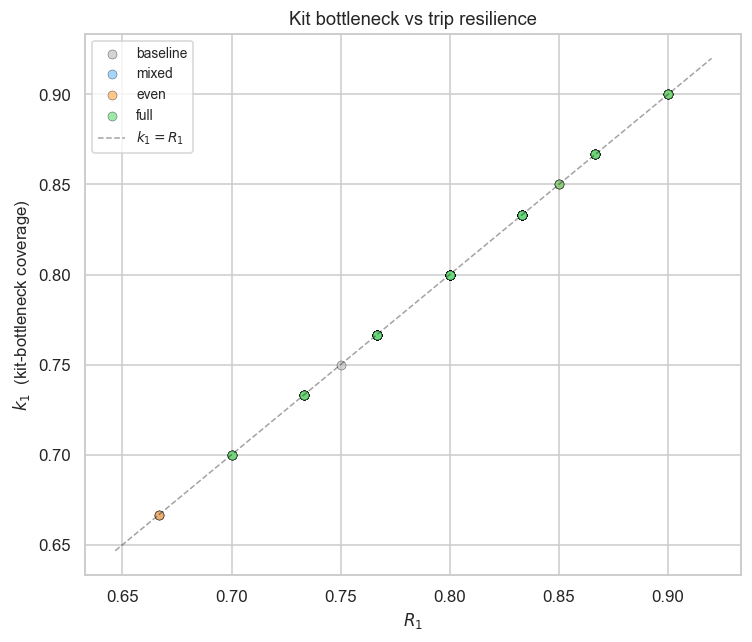

In [18]:
def plot_k1_vs_r1(df):
    fig, ax = plt.subplots(figsize=(7, 6))
    for cfg in CONFIG_ORDER:
        s = df[df["s2_config"] == cfg]
        ax.scatter(s["r_1"], s["k_1"], s=35, alpha=0.65,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.3,
                   label=cfg)
    lo = min(df["r_1"].min(), df["k_1"].min()) - 0.02
    hi = max(df["r_1"].max(), df["k_1"].max()) + 0.02
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, linewidth=1, label=r"$k_1 = R_1$")
    ax.set_xlabel(r"$R_1$")
    ax.set_ylabel(r"$k_1$  (kit-bottleneck coverage)")
    ax.set_title("Kit bottleneck vs trip resilience")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_k1_vs_r1(df)


### B5. Instance hardness — density / capacity tightness vs R_TR

We computed `density` (route fill of the directed graph) and `capacity_tightness`
(supply vs demand volume) post-hoc. Are they predictive of R_TR? If so, future
sweeps could bin instances by these instead of by name.

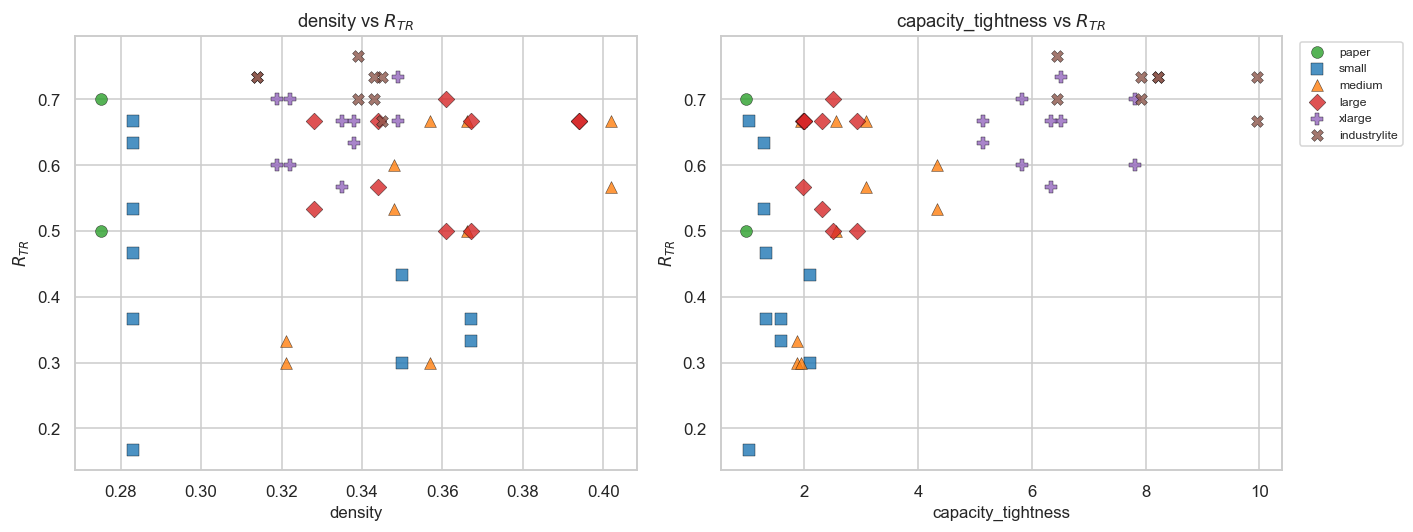

In [19]:
def plot_hardness_vs_rtr(df):
    sub = df[df["s2_config"] == "baseline"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric in zip(axes, ["density", "capacity_tightness"]):
        for size in SIZE_ORDER:
            s = sub[sub["instance_size"] == size]
            if s.empty:
                continue
            ax.scatter(s[metric], s["r_tr"],
                       color=SIZE_COLOR[size], marker=SIZE_MARKER[size],
                       s=60, alpha=0.8, edgecolor="black", linewidth=0.3,
                       label=size)
        ax.set_xlabel(metric)
        ax.set_ylabel(r"$R_{TR}$")
        ax.set_title(f"{metric} vs $R_{{TR}}$")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout(); plt.show()

plot_hardness_vs_rtr(df)


### B6. Cost-vs-resilience quadrant (Δ-cost % vs Δ-R_1 vs baseline)

For every non-baseline run we anchor against the matching `baseline` row (same
instance + weight) and plot the relative cost increase against the R_1 gain.
Upper-left = strictly dominated (more cost, worse R_1). Upper-right = pays for
resilience. Lower-right = free lunch.

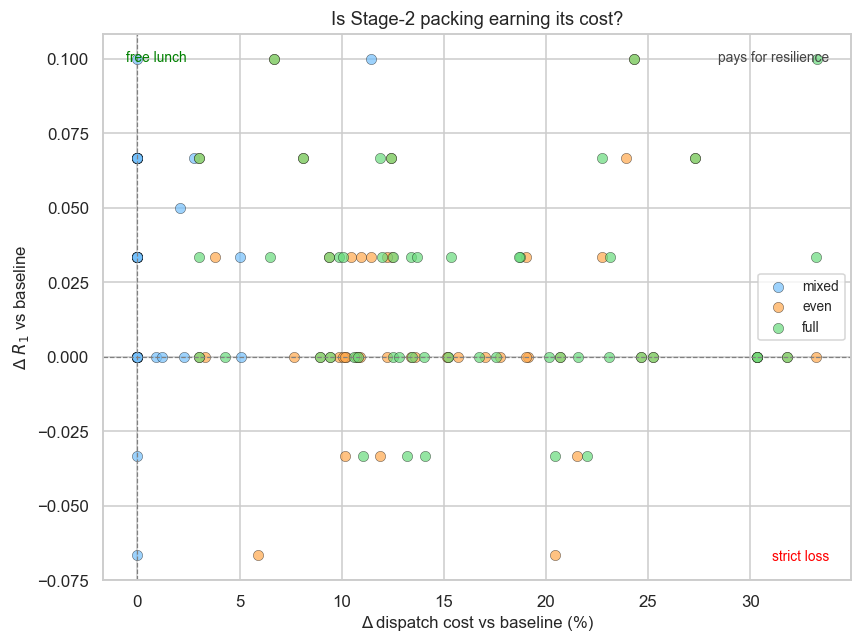

In [20]:
def plot_cost_vs_resilience_quadrant(df):
    base = (df[df["s2_config"] == "baseline"]
            .set_index(["instance_name", "weight"])[["s2_dispatch_cost", "r_1"]]
            .rename(columns={"s2_dispatch_cost": "base_cost", "r_1": "base_r1"}))
    m = df.join(base, on=["instance_name", "weight"], how="left")
    m = m[m["s2_config"] != "baseline"].copy()
    m["d_cost_pct"] = (m["s2_dispatch_cost"] - m["base_cost"]) / m["base_cost"] * 100
    m["d_r1"]       = m["r_1"] - m["base_r1"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for cfg in ["mixed", "even", "full"]:
        s = m[m["s2_config"] == cfg]
        ax.scatter(s["d_cost_pct"], s["d_r1"], s=45, alpha=0.7,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.3,
                   label=cfg)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Δ dispatch cost vs baseline (%)")
    ax.set_ylabel(r"Δ $R_1$ vs baseline")
    ax.text(0.97, 0.97, "pays for resilience",  transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="#444")
    ax.text(0.03, 0.97, "free lunch", transform=ax.transAxes,
            ha="left",  va="top", fontsize=9, color="green")
    ax.text(0.97, 0.03, "strict loss",  transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="red")
    ax.set_title("Is Stage-2 packing earning its cost?")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_cost_vs_resilience_quadrant(df)


### B7. S1 anytime trajectory — cost vs wall-clock for sample (instance, weight)

The trajectory JSON gives every improving solution clingo found. Plot a few
representative runs; the curve shape tells you whether the optimiser got stuck
on a plateau or steadily improved until the time limit.

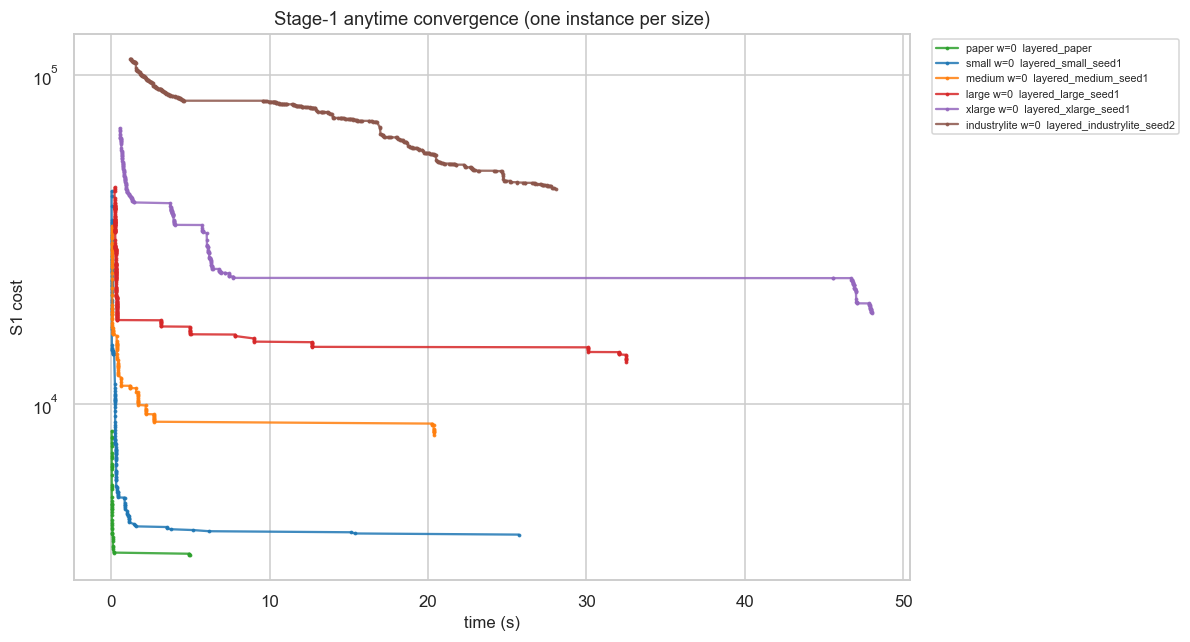

In [47]:
def plot_s1_trajectory_samples(df, k_per_size=1):
    # Pick one (instance, weight) per size to keep the plot readable
    rows = []
    for size in SIZE_ORDER:
        s = df[df["instance_size"] == size].drop_duplicates(["instance_name", "weight"])
        if not s.empty:
            rows.append(s.iloc[:k_per_size])
    picks = pd.concat(rows, ignore_index=True) if rows else df.head(0)

    fig, ax = plt.subplots(figsize=(11, 6))
    for _, row in picks.iterrows():
        try:
            traj = json.loads(row["s1_trajectory"])
        except Exception:
            continue
        if not traj:
            continue
        t = [p["time"] for p in traj]
        c = [p["cost"] for p in traj]
        ax.plot(t, c, marker=".", markersize=3, alpha=0.85,
                color=SIZE_COLOR.get(row["instance_size"], "gray"),
                label=f"{row['instance_size']} w={row['weight']}  {row['instance_name']}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("S1 cost")
    ax.set_title("Stage-1 anytime convergence (one instance per size)")
    ax.set_yscale("log")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout(); plt.show()

plot_s1_trajectory_samples(df)



### B8. S2 anytime trajectory — packing convergence

Stage-2 uses a multi-level objective `[soft, dispatch]`. Plot the leading
soft-constraint level over time; sharp drops mark the moment a feasible packing
was found.

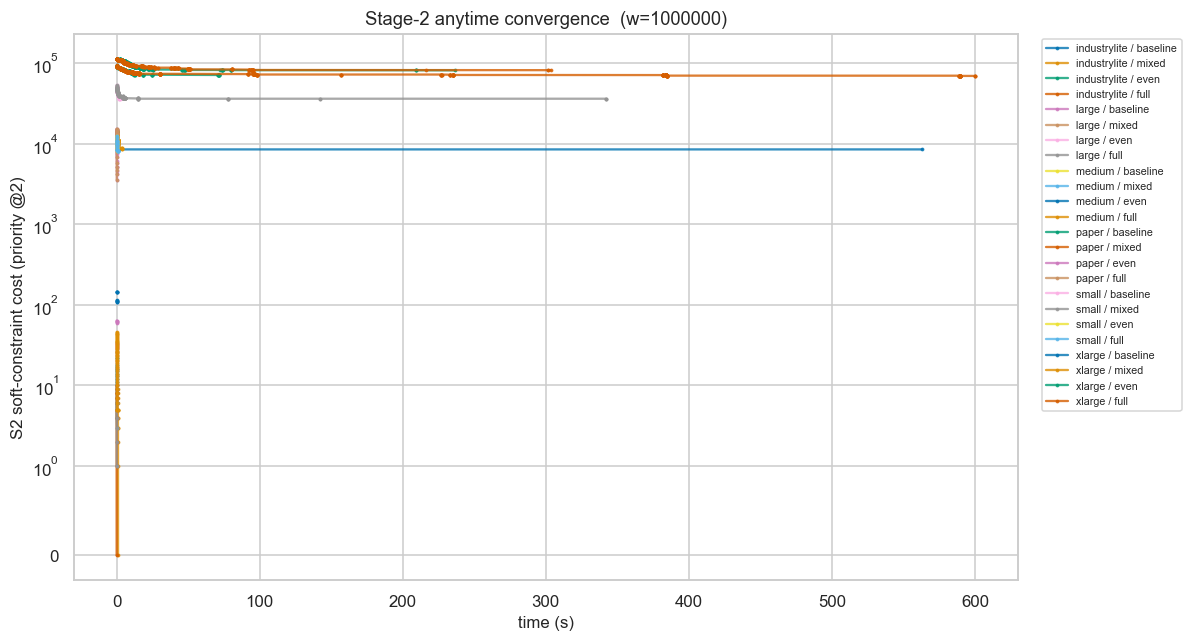

In [60]:
def plot_s2_trajectory_samples(df):
    fig, ax = plt.subplots(figsize=(11, 6))
    # show one trajectory per (size, s2_config) at high weight
    target_w = df["weight"].max()
    seen = set()
    for _, row in df[df["weight"] == target_w].iterrows():
        key = (row["instance_size"], row["s2_config"])
        if key in seen:
            continue
        try:
            traj = json.loads(row["s2_trajectory"])
        except Exception:
            continue
        if not traj:
            continue
        seen.add(key)
        t = [p["time"] for p in traj]
        c = [p["cost"][0] if isinstance(p["cost"], list) else p["cost"] for p in traj]
        ax.plot(t, c, marker=".", markersize=3, alpha=0.8,
                label=f"{row['instance_size']} / {row['s2_config']}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("S2 soft-constraint cost (priority @2)")
    ax.set_title(f"Stage-2 anytime convergence  (w={target_w})")
    ax.set_yscale("symlog", linthresh=1)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout(); plt.show()

plot_s2_trajectory_samples(df)


### B9. Per-instance cost-saving % heatmap (weight × s2_config)

Long-form heatmap, one row per (size, instance, weight), columns per config.
Spots the instances where Stage-2 packing genuinely saves on dispatch.

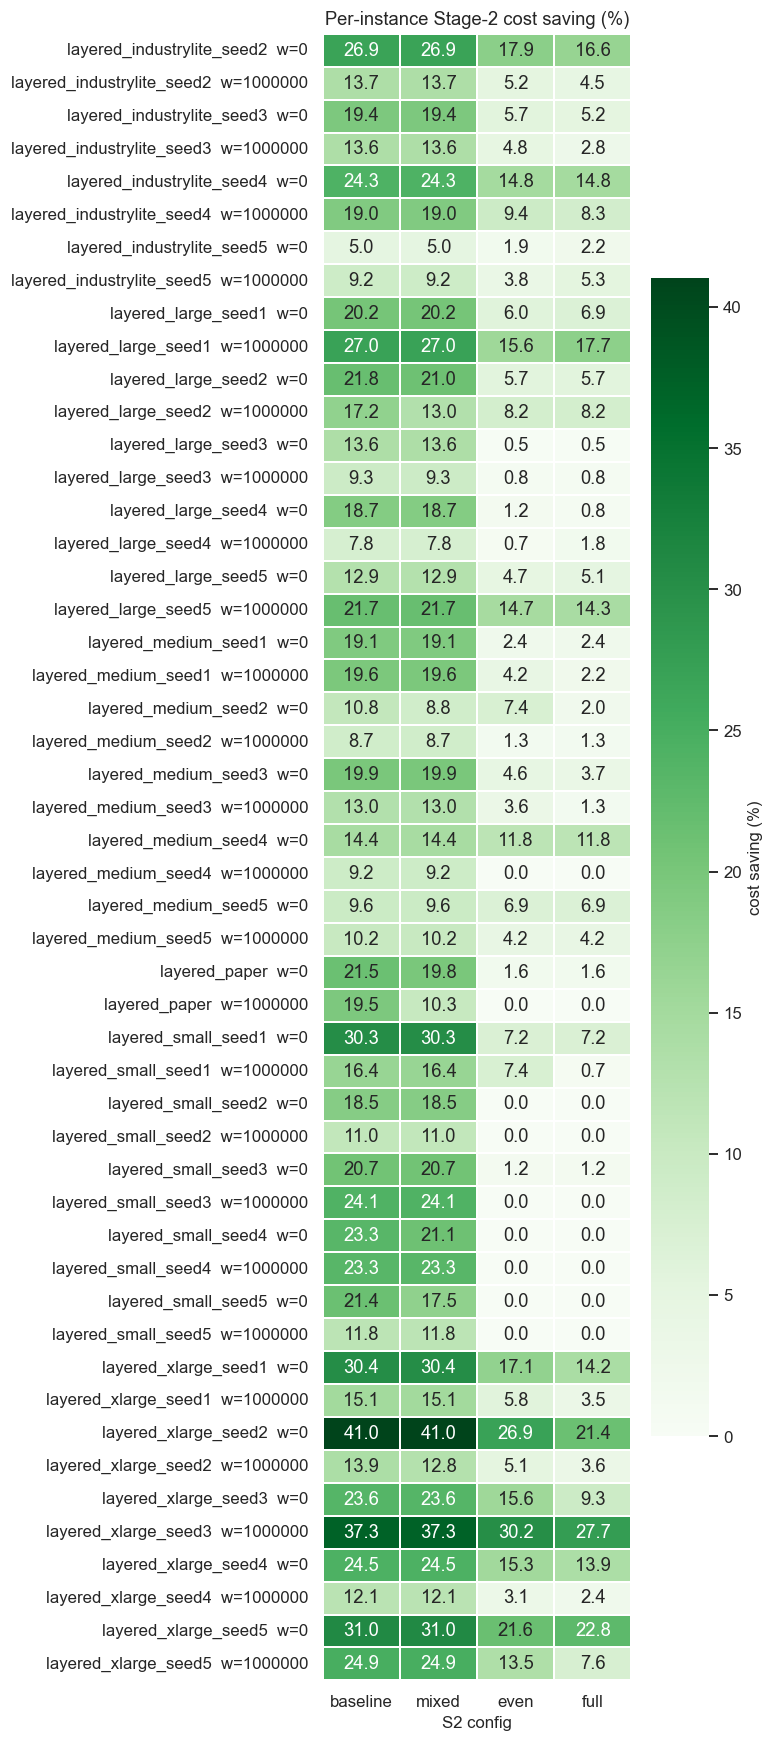

In [61]:
def plot_cost_saving_heatmap(df):
    sub = df.copy()
    sub["row"] = sub["instance_name"] + "  w=" + sub["weight"].astype(str)
    pivot = (sub.pivot_table(index="row", columns="s2_config",
                              values="cost_saving_pct", aggfunc="mean",
                              observed=True)
                .reindex(columns=CONFIG_ORDER))
    fig, ax = plt.subplots(figsize=(7, 0.28 * len(pivot) + 2))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Greens",
                cbar_kws={"label": "cost saving (%)"}, ax=ax,
                linewidths=0.3, linecolor="white")
    ax.set_xlabel("S2 config"); ax.set_ylabel("")
    ax.set_title("Per-instance Stage-2 cost saving (%)")
    fig.tight_layout(); plt.show()

plot_cost_saving_heatmap(df)


### B10. Stage time stacked bars per (size, weight) — where does wall-clock go?

The scalability chart averages over configs; here we keep `weight` separate so
we can see whether the resilience-priority weight is driving the timeout.

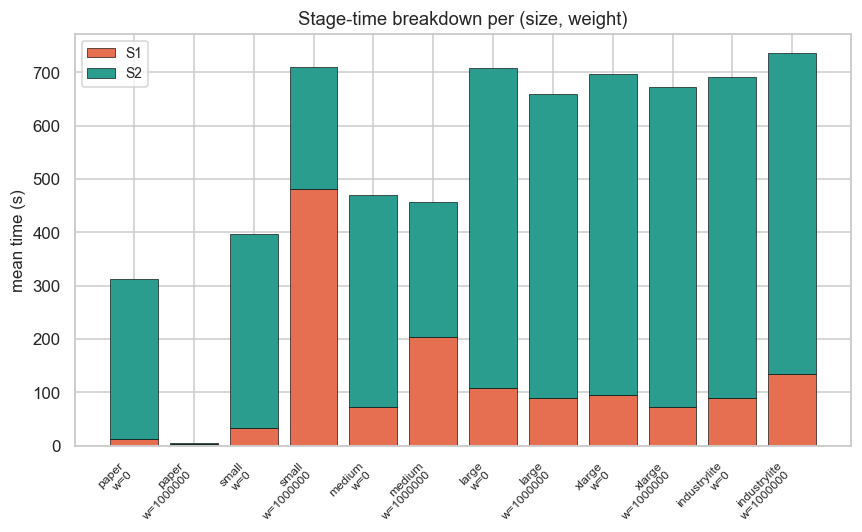

In [62]:
def plot_time_stack(df):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    weights = sorted(df["weight"].unique())
    x_labels = [f"{s}\nw={w}" for s in sizes for w in weights]
    s1, s2 = [], []
    for s in sizes:
        for w in weights:
            sub = df[(df["instance_size"] == s) & (df["weight"] == w)]
            s1.append(sub["s1_time"].mean()); s2.append(sub["s2_time"].mean())
    x = np.arange(len(x_labels))
    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(x_labels)), 5))
    ax.bar(x, s1, label="S1", color="#e76f51", edgecolor="black", linewidth=0.4)
    ax.bar(x, s2, bottom=s1, label="S2", color="#2a9d8f", edgecolor="black", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("mean time (s)")
    ax.set_title("Stage-time breakdown per (size, weight)")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_time_stack(df)


### B11. Bottleneck part / arc / trip frequency

Symbolic columns `worst_arc`, `worst_trip`, `kit_bottleneck_part` are the
identifiers of whichever object set the resilience score. Aggregating their
counts shows whether a handful of arcs/parts are responsible for most failures.

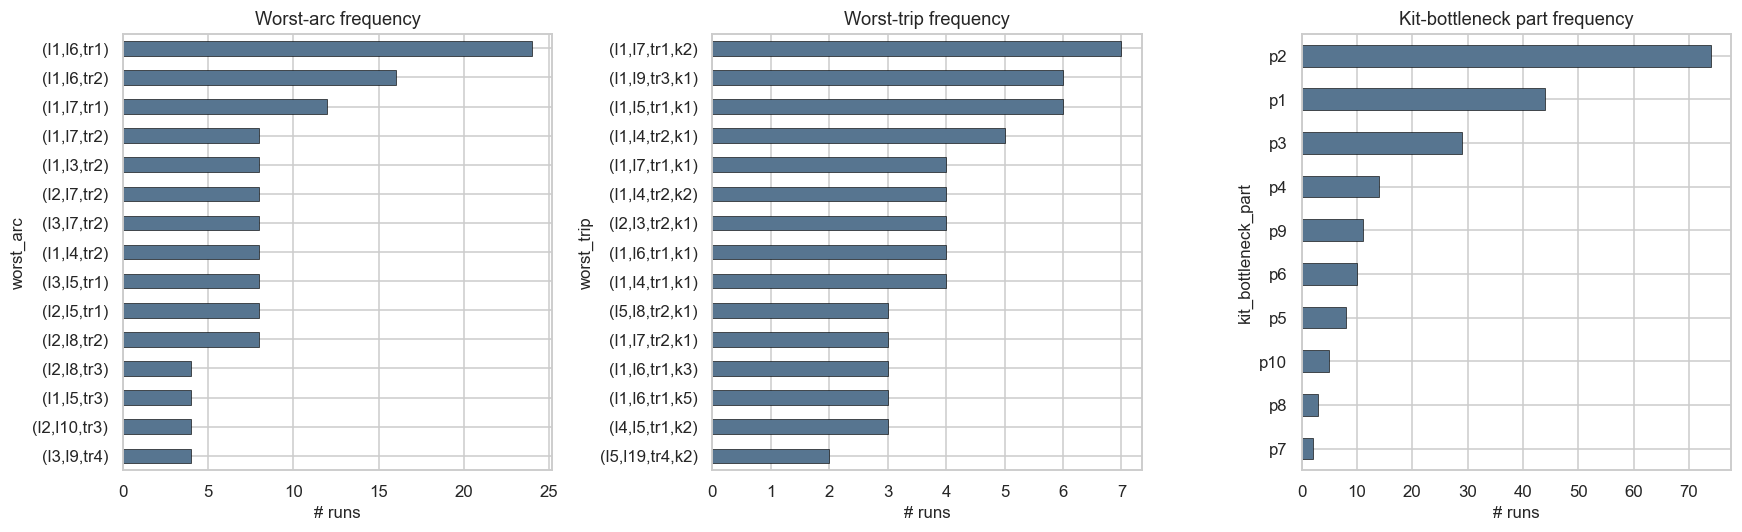

In [63]:
def plot_bottleneck_frequencies(df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title in [
        (axes[0], "worst_arc",            "Worst-arc frequency"),
        (axes[1], "worst_trip",           "Worst-trip frequency"),
        (axes[2], "kit_bottleneck_part",  "Kit-bottleneck part frequency"),
    ]:
        s = df[col].dropna().astype(str)
        s = s[s != ""]
        top = s.value_counts().head(15)
        if top.empty:
            ax.set_title(f"{title}\n(no data)")
            ax.axis("off"); continue
        top.plot(kind="barh", ax=ax, color="#577590", edgecolor="black", linewidth=0.4)
        ax.invert_yaxis()
        ax.set_title(title)
        ax.set_xlabel("# runs")
    fig.tight_layout(); plt.show()

plot_bottleneck_frequencies(df)


### B12. R_α area-under-curve (AUC) — single number per (size, config)

Trapezoidal integral of R_α(α) over α ∈ [0.2, 0.8]. Compresses the four-point
degradation curve into one comparison number. Higher = more robust to
partial disruption.

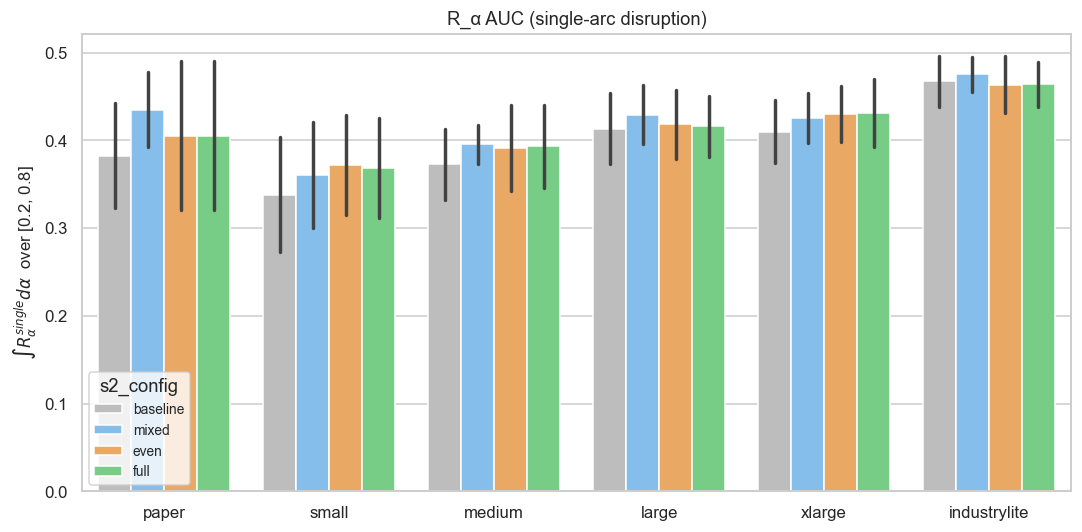

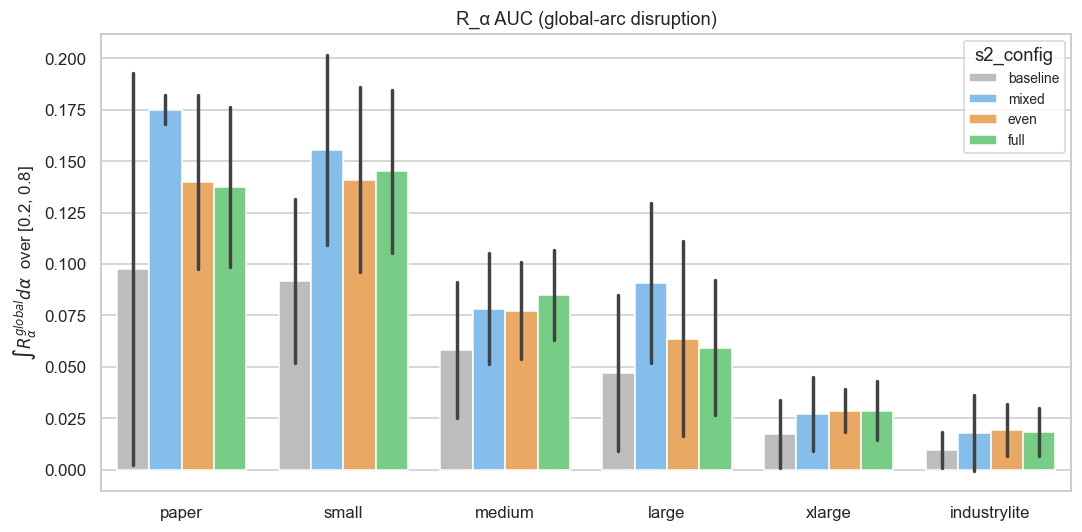

In [64]:
def plot_ralpha_auc(df, mode="single"):
    sub = df.copy()
    cols = [f"r_heaviest_{mode}_{a}" for a in ALPHAS]
    trapz = getattr(np, "trapezoid", None) or np.trapz  # numpy 2.x rename
    sub["auc"] = trapz(sub[cols].values, x=ALPHAS, axis=1)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=sub, x="instance_size", y="auc",
                hue="s2_config", order=SIZE_ORDER,
                hue_order=CONFIG_ORDER,
                palette=CONFIG_COLOR, ax=ax,
                errorbar="sd")
    ax.set_ylabel(fr"$\int R_\alpha^{{{mode}}} d\alpha$  over [0.2, 0.8]")
    ax.set_xlabel("")
    ax.set_title(f"R_α AUC ({mode}-arc disruption)")
    fig.tight_layout(); plt.show()

plot_ralpha_auc(df, "single")
plot_ralpha_auc(df, "global")


### B13. R_α curves overlaid w=0 vs w=1e6 per size

Solid line = high weight, dashed = w=0. Four configs per panel, two modes
(single + global) side-by-side. Anywhere the dashed line sits *above* the solid
line means the high diversification weight made R_α **worse** at that α —
the regression we suspected from the aggregate numbers.

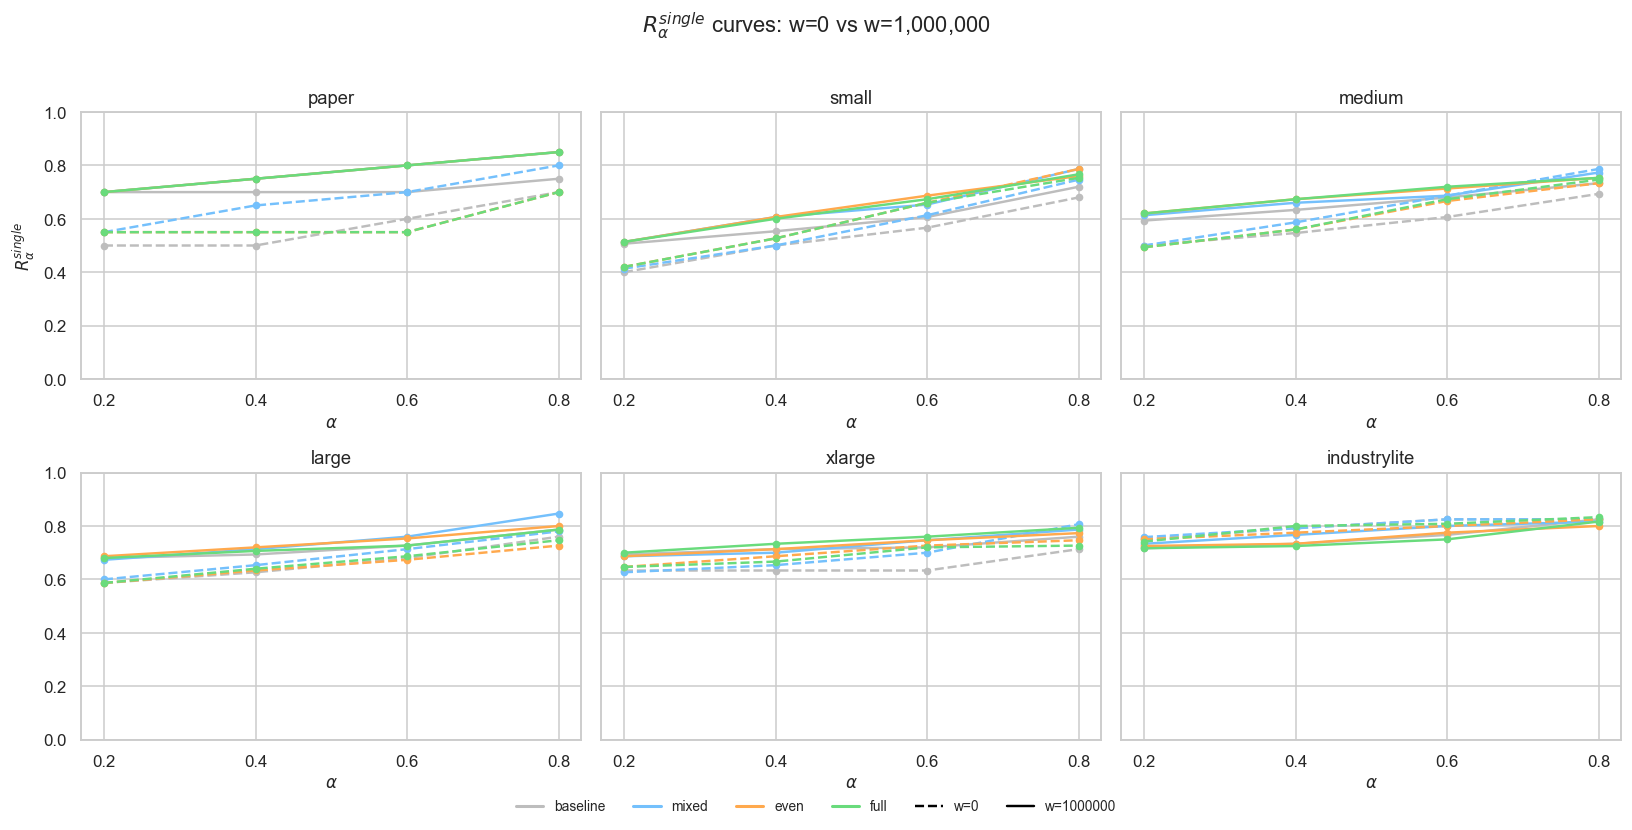

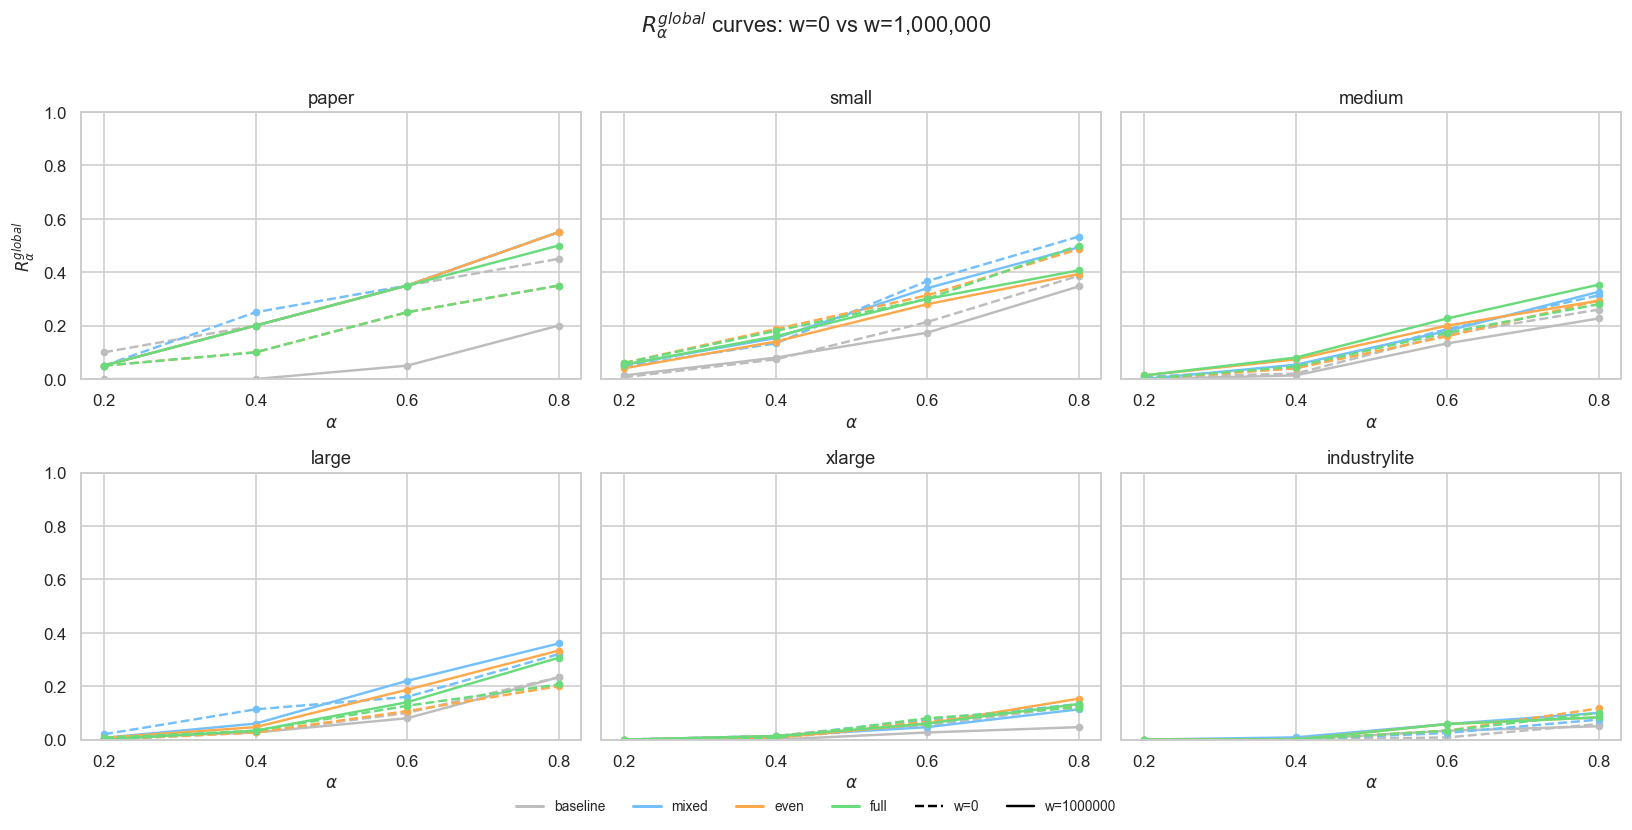

In [65]:
def plot_ralpha_curves_both_weights(df, mode="single"):
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    n = len(sizes)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows),
                              sharey=True, squeeze=False)
    for ax, size in zip(axes.flat, sizes):
        s = df[df["instance_size"] == size]
        for cfg in CONFIG_ORDER:
            for w, style in [(0, "--"), (df["weight"].max(), "-")]:
                cs = s[(s["s2_config"] == cfg) & (s["weight"] == w)]
                if cs.empty:
                    continue
                ys = [cs[f"r_heaviest_{mode}_{a}"].mean() for a in ALPHAS]
                ax.plot(ALPHAS, ys, style, marker="o",
                        color=CONFIG_COLOR[cfg], linewidth=1.6, markersize=4,
                        label=f"{cfg} w={w}" if ax is axes.flat[0] else None)
        ax.set_xticks(ALPHAS)
        ax.set_xlabel(r"$\alpha$")
        ax.set_title(size)
        ax.set_ylim(0, 1)
        if ax is axes.flat[0]:
            ax.set_ylabel(fr"$R_\alpha^{{{mode}}}$")
    # Hide unused axes
    for ax in axes.flat[len(sizes):]:
        ax.set_visible(False)
    # Single legend at figure level — config colour + line-style key
    handles = [plt.Line2D([], [], color=CONFIG_COLOR[c], lw=2, label=c)
               for c in CONFIG_ORDER]
    handles += [plt.Line2D([], [], color="black", lw=1.6, ls="--", label="w=0"),
                plt.Line2D([], [], color="black", lw=1.6, ls="-",
                           label=f"w={df['weight'].max()}")]
    fig.legend(handles=handles, loc="lower center", ncol=6,
               bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
    fig.suptitle(fr"$R_\alpha^{{{mode}}}$ curves: w=0 vs w={df['weight'].max():,}", y=1.01)
    fig.tight_layout(); plt.show()

plot_ralpha_curves_both_weights(df, "single")
plot_ralpha_curves_both_weights(df, "global")


### B14. R_α AUC delta (w=1e6 − w=0) per size × config

Same data, one number per (size, config). Red bars = high weight *hurt* R_α.
Two panels: single-arc and global. The bar values are the trapezoidal area
change of the α-curve between the two weights.

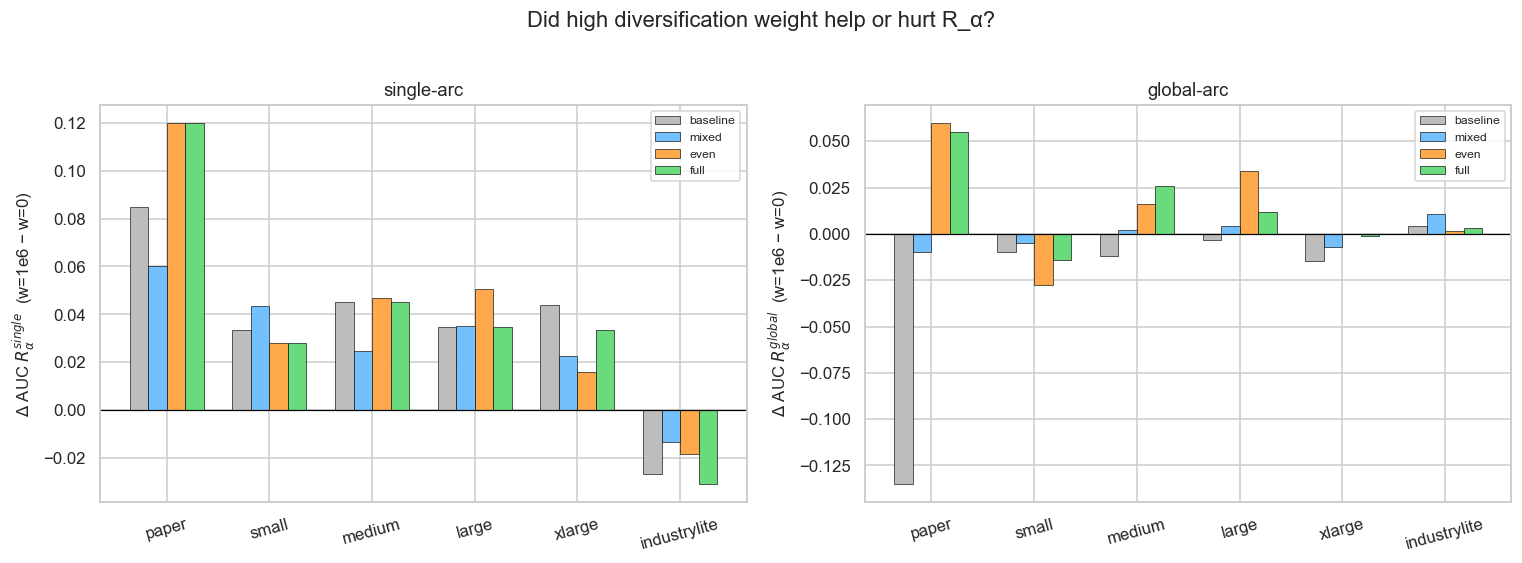

In [66]:
def plot_ralpha_auc_delta(df):
    trapz = getattr(np, "trapezoid", None) or np.trapz
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mode in zip(axes, ["single", "global"]):
        x = np.arange(len(sizes))
        width = 0.18
        for i, cfg in enumerate(CONFIG_ORDER):
            deltas = []
            for size in sizes:
                vals = []
                for w in [0, df["weight"].max()]:
                    s = df[(df["instance_size"] == size)
                           & (df["s2_config"] == cfg)
                           & (df["weight"] == w)]
                    means = [s[f"r_heaviest_{mode}_{a}"].mean() for a in ALPHAS]
                    vals.append(trapz(means, x=ALPHAS))
                deltas.append(vals[1] - vals[0])
            ax.bar(x + (i - 1.5) * width, deltas, width,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.4,
                   label=cfg)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xticks(x); ax.set_xticklabels(sizes, rotation=15)
        ax.set_ylabel(fr"Δ AUC $R_\alpha^{{{mode}}}$  (w=1e6 − w=0)")
        ax.set_title(f"{mode}-arc")
        ax.legend(fontsize=8)
    fig.suptitle("Did high diversification weight help or hurt R_α?", y=1.02)
    fig.tight_layout(); plt.show()

plot_ralpha_auc_delta(df)


### B15. R_α cost-tradeoff (per size, per config)

Ported from old `plot_ralpha_cost_tradeoff`. Each line = one Stage-2 config,
endpoints are the two extreme weights, X = mean global R_α at α=0.8 (%),
Y = S2 dispatch cost increase relative to `baseline` at w=0 (%). Read as:
"how much extra do you pay to get more disruption tolerance?"

One figure per instance size.

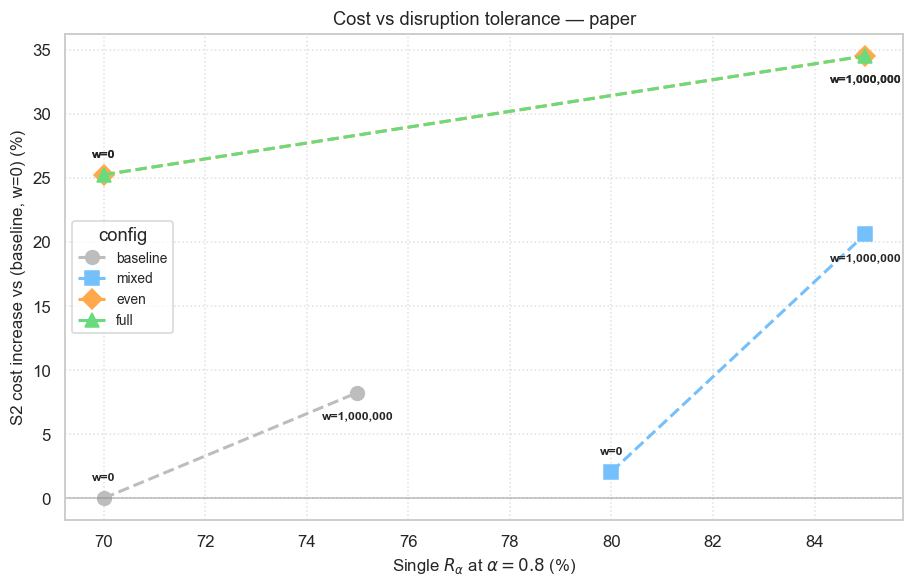

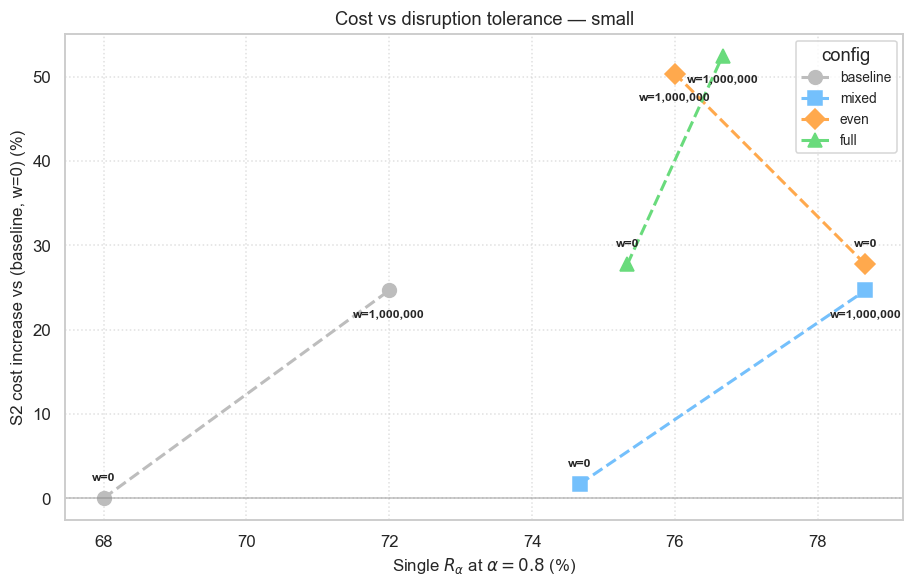

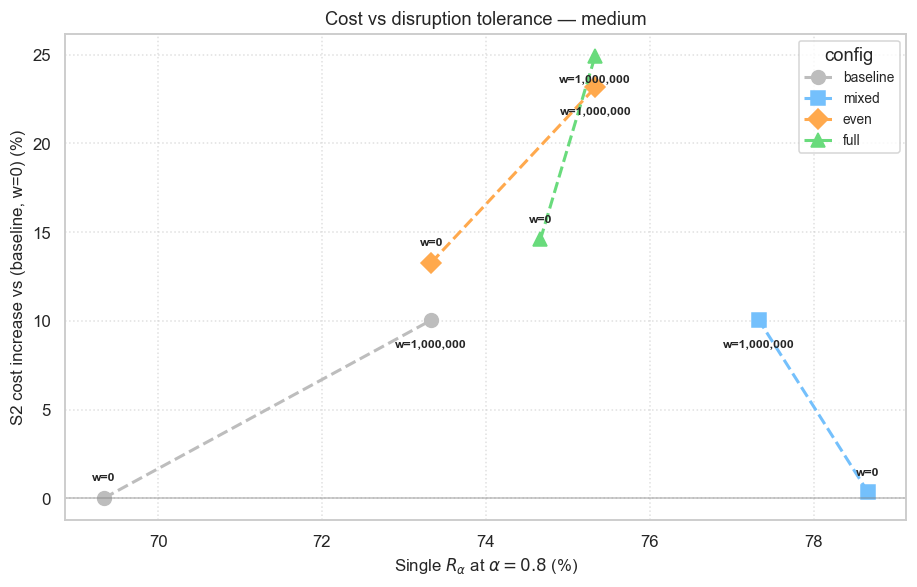

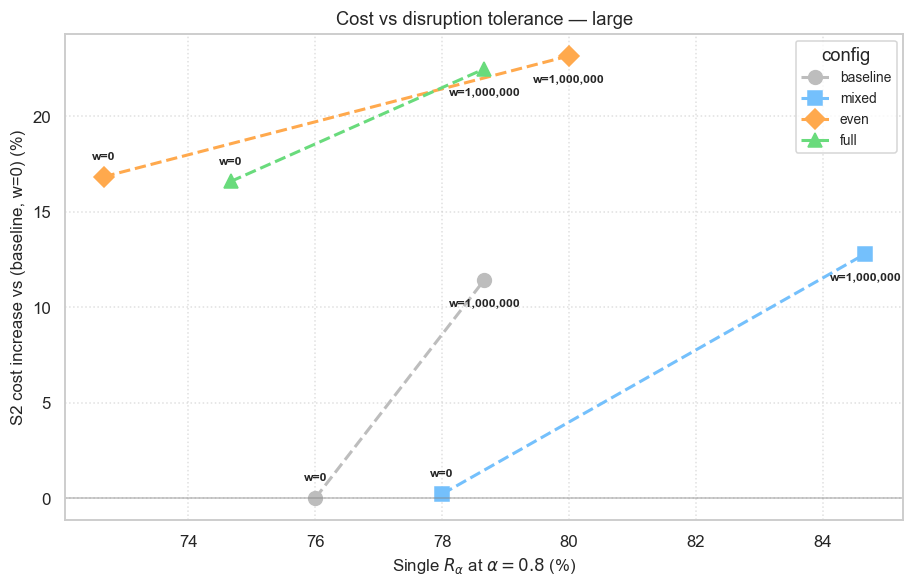

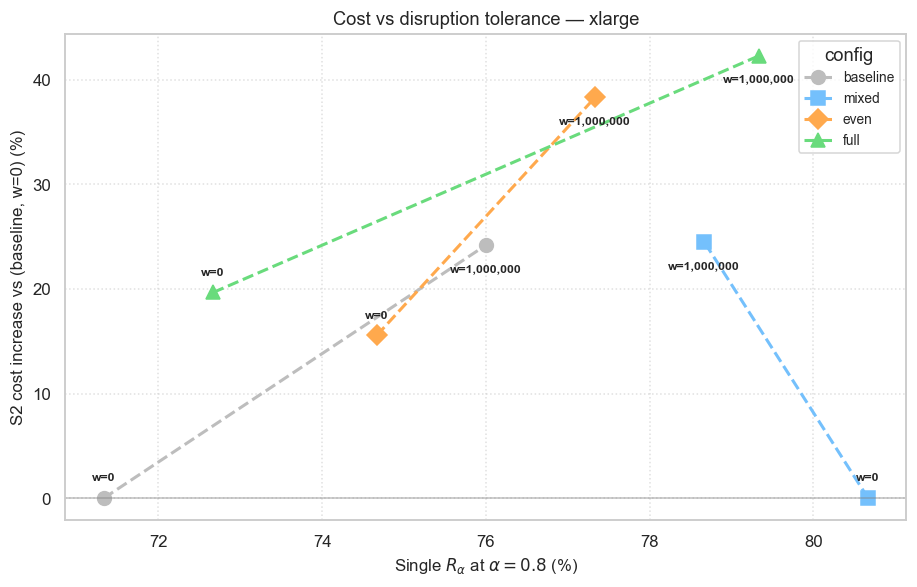

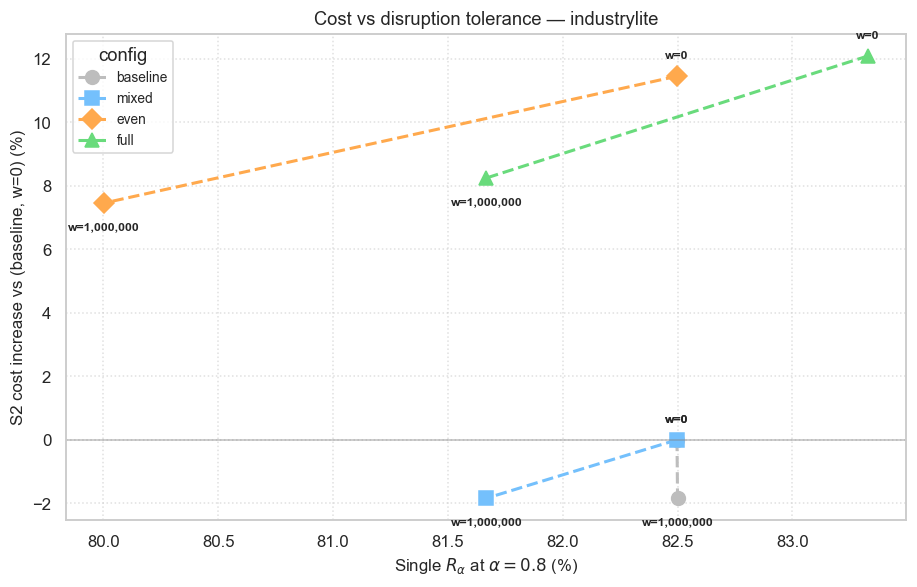

In [67]:
def plot_ralpha_cost_tradeoff(df, alpha=0.8, mode="single"):
    col = f"r_heaviest_{mode}_{alpha}"
    if col not in df.columns:
        print(f"[SKIP] missing {col}")
        return

    markers = {"baseline": "o", "mixed": "s", "even": "D", "full": "^"}
    sizes = [s for s in SIZE_ORDER if (df["instance_size"] == s).any()]

    for target_size in sizes:
        sub = df[df["instance_size"] == target_size]
        if sub.empty:
            continue

        # Reference cost: baseline @ w=0
        ref = sub[(sub["weight"] == 0) & (sub["s2_config"] == "baseline")]
        if ref.empty:
            continue
        c0 = ref["s2_dispatch_cost"].mean()

        fig, ax = plt.subplots(figsize=(8.5, 5.5))
        weights = sorted(sub["weight"].unique())
        endpoints = {int(weights[0]), int(weights[-1])} if weights else set()

        for cfg in CONFIG_ORDER:
            cs = sub[sub["s2_config"] == cfg]
            if cs.empty:
                continue
            pts = []
            for w in weights:
                if int(w) not in endpoints:
                    continue
                ws = cs[cs["weight"] == w]
                if ws.empty:
                    continue
                r_val = ws[col].mean() * 100
                cost_pct = (ws["s2_dispatch_cost"].mean() - c0) / c0 * 100
                pts.append((r_val, cost_pct, int(w)))
            if not pts:
                continue
            pts.sort(key=lambda p: p[2])
            r_vals = [p[0] for p in pts]
            cost_vals = [p[1] for p in pts]
            ax.plot(r_vals, cost_vals, f"{markers[cfg]}--",
                    linewidth=2, markersize=9,
                    color=CONFIG_COLOR[cfg], label=cfg)
            offsets = [(0, 10, "center", "bottom"),
                       (0, -12, "center", "top"),
                       (8, 0, "left", "center"),
                       (-8, 0, "right", "center")]
            for i, (r, c, w) in enumerate(pts):
                dx, dy, ha, va = offsets[i % len(offsets)]
                ax.annotate(f"w={w:,}", (r, c), textcoords="offset points",
                            xytext=(dx, dy), fontsize=8, fontweight="bold",
                            ha=ha, va=va)

        ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
        ax.set_xlabel(fr"{mode.title()} $R_\alpha$ at $\alpha={alpha}$ (%)")
        ax.set_ylabel("S2 cost increase vs (baseline, w=0) (%)")
        ax.set_title(f"Cost vs disruption tolerance — {target_size}")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(title="config", fontsize=9)
        fig.tight_layout(); plt.show()

plot_ralpha_cost_tradeoff(df, alpha=0.8, mode="single")


### B16. Cost increase vs R_TR — all sizes on one plot

Ported from old `plot_cost_increase_vs_rtr`. One line per size, two points
(w=0 and w=max). X = mean R_TR (%), Y = S2 dispatch cost increase relative
to the size's own w=0 baseline (%). Uses baseline S2 config to isolate the
Stage-1 weight effect.

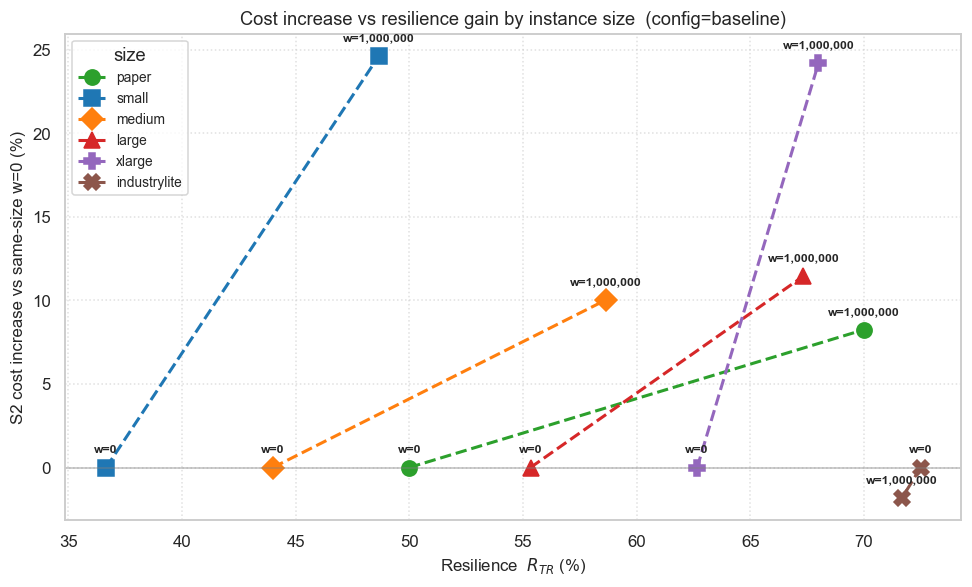

In [72]:
def plot_cost_increase_vs_rtr(df):
    sub = df[df["s2_config"] == "baseline"].copy()
    sizes = [s for s in SIZE_ORDER if (sub["instance_size"] == s).any()]
    weights = sorted(sub["weight"].unique())
    if len(weights) < 2:
        print("[SKIP] need >=2 weights")
        return
    w_lo, w_hi = int(weights[0]), int(weights[-1])
    markers = ["o", "s", "D", "^", "P", "X"]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for i, size in enumerate(sizes):
        s = sub[sub["instance_size"] == size]
        ref = s[s["weight"] == w_lo]
        if ref.empty:
            continue
        c0 = ref["s2_dispatch_cost"].mean()
        pts = []
        for w in [w_lo, w_hi]:
            ws = s[s["weight"] == w]
            if ws.empty:
                continue
            rtr = ws["r_tr"].mean() * 100
            cost_pct = (ws["s2_dispatch_cost"].mean() - c0) / c0 * 100
            pts.append((rtr, cost_pct, int(w)))
        if len(pts) < 2:
            continue
        rtrs = [p[0] for p in pts]
        pcts = [p[1] for p in pts]
        ax.plot(rtrs, pcts, "--", linewidth=2, markersize=10,
                color=SIZE_COLOR[size], marker=markers[i % len(markers)],
                label=size)
        for rtr, pct, w in pts:
            ax.annotate(f"w={w:,}", (rtr, pct), textcoords="offset points",
                        xytext=(0, 10), ha="center", fontsize=8,
                        fontweight="bold")

    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.set_xlabel(r"Resilience  $R_{TR}$ (%)")
    ax.set_ylabel("S2 cost increase vs same-size w=0 (%)")
    ax.set_title("Cost increase vs resilience gain by instance size  (config=baseline)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(title="size", fontsize=9)
    fig.tight_layout(); plt.show()

plot_cost_increase_vs_rtr(df)


---
## Summary table

Mean of the headline metrics grouped by (size, weight, s2_config). Useful for
spot-checking the plots and pasting into prose.

In [73]:
summary = (df.groupby(["instance_size", "weight", "s2_config"], observed=True)
             .agg(r_tr=("r_tr", "mean"),
                  r_1 =("r_1",  "mean"),
                  k_1 =("k_1",  "mean"),
                  exposure=("exposure_count", "mean"),
                  mono=("mono_count", "mean"),
                  conc=("concentrated_count", "mean"),
                  s1_cost=("s1_dispatch_cost", "mean"),
                  s2_cost=("s2_dispatch_cost", "mean"),
                  save_pct=("cost_saving_pct", "mean"),
                  s1_time=("s1_time", "mean"),
                  s2_time=("s2_time", "mean"),
                  s1_opt=("s1_optimal", "mean"),
                  s2_opt=("s2_optimal", "mean"),
                  n=("r_tr", "size"))
             .round(3))
summary


r_tr    r_1    k_1  exposure   mono    conc  \
instance_size weight  s2_config                                                 
paper         0       baseline   0.500  0.800  0.800       5.0   9.00   22.00   
                      mixed      0.500  0.850  0.850       5.0   0.00   21.00   
                      even       0.500  0.800  0.800       5.0  11.00   12.00   
                      full       0.500  0.800  0.800       5.0  11.00   12.00   
              1000000 baseline   0.700  0.750  0.750       0.0  10.00   19.00   
                      mixed      0.700  0.850  0.850       0.0   0.00   10.00   
                      even       0.700  0.850  0.850       0.0   0.00    4.00   
                      full       0.700  0.850  0.850       0.0   0.00    4.00   
small         0       baseline   0.367  0.800  0.800       4.2  13.40   27.60   
                      mixed      0.367  0.833  0.833       4.2   1.80   33.20   
                      even       0.367  0.820  0.820       4.2  12.00   15.40   
                      full       0.367  0.833  0.833       4.2  10.80   15.40   
              1000000 baseline   0.487  0.793  0.793       0.8  11.00   24.60   
                      mixed      0.487  0.840  0.840       0.8   1.40   26.60   
                      even       0.487  0.807  0.807       0.8   6.00   12.60   
                      full       0.487  0.820  0.820       0.8   4.80   12.60   
medium        0       baseline   0.440  0.767  0.767       3.2  11.60   31.40   
                      mixed      0.440  0.787  0.787       3.2   1.40   34.40   
                      even       0.440  0.787  0.787       3.2   7.80   17.60   
                      full       0.440  0.793  0.793       3.2   6.60   17.60   
              1000000 baseline   0.587  0.733  0.733       0.6  14.60   30.00   
                      mixed      0.587  0.773  0.773       0.6   2.60   32.40   
                      even       0.587  0.767  0.767       0.6   8.20   15.40   
                      full       0.587  0.773  0.773       0.6   6.80   15.40   
large         0       baseline   0.553  0.840  0.840       2.2  21.60   70.20   
                      mixed      0.553  0.853  0.853       2.2   3.20   81.80   
                      even       0.553  0.820  0.820       2.2  29.40   44.80   
                      full       0.553  0.827  0.827       2.2  29.40   44.40   
              1000000 baseline   0.673  0.827  0.827       0.0  29.00   64.80   
                      mixed      0.673  0.860  0.860       0.0   4.20   79.80   
                      even       0.673  0.833  0.833       0.0  30.00   43.80   
                      full       0.673  0.840  0.840       0.0  28.80   43.80   
xlarge        0       baseline   0.627  0.753  0.753       1.2  21.00  107.00   
                      mixed      0.627  0.813  0.813       1.2   1.40  113.60   
                      even       0.627  0.787  0.787       1.2  24.40   73.80   
                      full       0.627  0.793  0.793       1.2  29.00   73.40   
              1000000 baseline   0.680  0.780  0.780       0.0  27.20  113.40   
                      mixed      0.680  0.787  0.787       0.0   1.80  121.00   
                      even       0.680  0.787  0.787       0.0  26.00   80.80   
                      full       0.680  0.793  0.793       0.0  30.40   80.00   
industrylite  0       baseline   0.725  0.825  0.825       0.0  24.75  218.00   
                      mixed      0.725  0.825  0.825       0.0   1.50  219.75   
                      even       0.725  0.833  0.833       0.0  45.75  170.00   
                      full       0.725  0.833  0.833       0.0  47.25  169.25   
              1000000 baseline   0.717  0.825  0.825       0.0  28.00  221.25   
                      mixed      0.717  0.817  0.817       0.0   0.75  222.50   
                      even       0.717  0.800  0.800       0.0  42.25  169.50   
                      full       0.717  0.817  0.817       0.0  4

## C1. Cross-comparison: one-shot vs two-stage

Compares the benchmark one-shot encodings (naive/clingcon) against the two-stage
decomposition on the instances both experiments cover:
- Solve time: one-shot total vs S1+S2 combined
- Solution quality: one-shot cost vs S1 nominal cost
- Average solve-time breakdown

Reads the per-size summary CSVs from `experiments/benchmark/results/`; skips
gracefully when none are present.

In [74]:
# Load benchmark one-shot summaries (per-size CSVs)
BENCH_DIR = Path("../../benchmark/results")
bench_files = sorted(BENCH_DIR.glob("benchmark_summary_*.csv"))
if bench_files:
    bench = pd.concat([pd.read_csv(f) for f in bench_files], ignore_index=True)
    print(f"Loaded benchmark: {len(bench)} rows from {len(bench_files)} files")
    print(f"Solvers: {bench['solver'].unique()}")
    print(f"Sizes: {bench['instance_size'].unique()}")
else:
    bench = None
    print(f"No benchmark_summary_*.csv under {BENCH_DIR.resolve()} — skipping cross-comparison")


Loaded benchmark: 282 rows from 4 files
Solvers: <StringArray>
['clingcon', 'clingcon_optimised', 'naive_basic', 'naive_optimised']
Length: 4, dtype: str
Sizes: <StringArray>
['medium', 'paper', 'small']
Length: 3, dtype: str


Cross-comparison on 11 instances:
  ['layered_medium_seed1', 'layered_medium_seed2', 'layered_medium_seed3', 'layered_medium_seed4', 'layered_medium_seed5', 'layered_paper', 'layered_small_seed1', 'layered_small_seed2', 'layered_small_seed3', 'layered_small_seed4', 'layered_small_seed5']


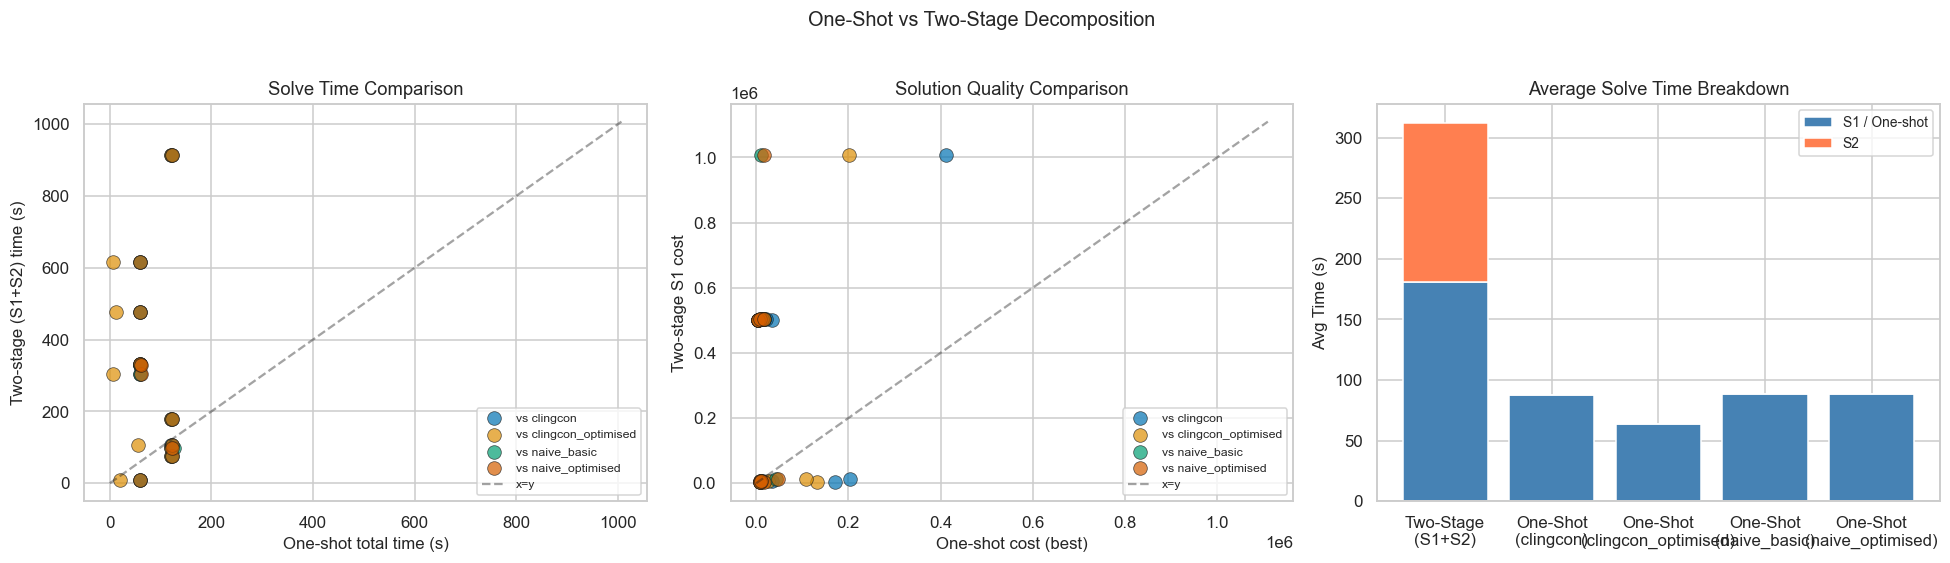


--- Cross-comparison summary ---

  vs clingcon (11 instances):
    Avg one-shot time:  87.31s
    Avg two-stage time: 312.44s
    Speedup factor:     0.3x
    Avg one-shot cost:  85091
    Avg two-stage cost: 323532

  vs clingcon_optimised (11 instances):
    Avg one-shot time:  63.51s
    Avg two-stage time: 312.44s
    Speedup factor:     0.2x
    Avg one-shot cost:  48116
    Avg two-stage cost: 323532

  vs naive_basic (11 instances):
    Avg one-shot time:  88.84s
    Avg two-stage time: 312.44s
    Speedup factor:     0.3x
    Avg one-shot cost:  12393
    Avg two-stage cost: 323532

  vs naive_optimised (11 instances):
    Avg one-shot time:  88.88s
    Avg two-stage time: 312.44s
    Speedup factor:     0.3x
    Avg one-shot cost:  13861
    Avg two-stage cost: 323532


In [75]:
def plot_cross_comparison(df_twostage, df_bench):
    # Compare one-shot vs two-stage: time, cost, grounding.
    if df_bench is None:
        print("No benchmark data loaded — skipping cross-comparison")
        return

    # --- Prepare two-stage summary (one row per instance × weight, baseline config) ---
    ts = df_twostage[df_twostage["s2_config"] == "baseline"].copy()
    ts["total_time"] = ts["s1_time"] + ts["s2_time"]
    ts_agg = ts.groupby(["instance_name", "instance_size"]).agg(
        ts_total_time=("total_time", "mean"),
        ts_s1_time=("s1_time", "mean"),
        ts_s2_time=("s2_time", "mean"),
        ts_cost=("nominal_cost", "mean"),
    ).reset_index()

    # --- Prepare benchmark summary (best cost per instance × solver) ---
    # Use num_bins with best cost for each solver
    bench_best = df_bench.loc[
        df_bench.groupby(["solver", "instance"])["cost"].idxmin()
    ].copy()
    bench_best = bench_best.rename(columns={
        "instance": "instance_name",
        "avg_total_time": "os_total_time",
        "cost": "os_cost",
        "atoms": "os_atoms",
    })

    # --- Merge on instance name ---
    common_instances = set(ts_agg["instance_name"]) & set(bench_best["instance_name"])
    if not common_instances:
        print("No common instances between two-stage and benchmark")
        print(f"  Two-stage instances: {ts_agg['instance_name'].unique()[:5]}")
        print(f"  Benchmark instances: {bench_best['instance_name'].unique()[:5]}")
        return

    merged = ts_agg[ts_agg["instance_name"].isin(common_instances)].merge(
        bench_best[["instance_name", "solver", "os_total_time", "os_cost", "os_atoms"]],
        on="instance_name", how="inner"
    )

    if merged.empty:
        print("No overlapping data after merge")
        return

    print(f"Cross-comparison on {len(common_instances)} instances:")
    print(f"  {sorted(common_instances)}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Panel 1: Solve Time ---
    ax = axes[0]
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        ax.scatter(s_df["os_total_time"], s_df["ts_total_time"],
                   label=f"vs {solver}", s=80, alpha=0.7, edgecolors="k", linewidths=0.5)
    max_time = max(merged["os_total_time"].max(), merged["ts_total_time"].max()) * 1.1
    ax.plot([0, max_time], [0, max_time], "k--", alpha=0.4, label="x=y")
    ax.set_xlabel("One-shot total time (s)")
    ax.set_ylabel("Two-stage (S1+S2) time (s)")
    ax.set_title("Solve Time Comparison")
    ax.legend(fontsize=8)

    # --- Panel 2: Solution Cost ---
    ax = axes[1]
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        ax.scatter(s_df["os_cost"], s_df["ts_cost"],
                   label=f"vs {solver}", s=80, alpha=0.7, edgecolors="k", linewidths=0.5)
    max_cost = max(merged["os_cost"].max(), merged["ts_cost"].max()) * 1.1
    ax.plot([0, max_cost], [0, max_cost], "k--", alpha=0.4, label="x=y")
    ax.set_xlabel("One-shot cost (best)")
    ax.set_ylabel("Two-stage S1 cost")
    ax.set_title("Solution Quality Comparison")
    ax.legend(fontsize=8)

    # --- Panel 3: Time breakdown bar ---
    ax = axes[2]
    # Average times by approach
    ts_times = ts_agg[ts_agg["instance_name"].isin(common_instances)]
    avg_s1 = ts_times["ts_s1_time"].mean()
    avg_s2 = ts_times["ts_s2_time"].mean()

    bar_data = {"Two-Stage\n(S1+S2)": [avg_s1, avg_s2]}
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        bar_data[f"One-Shot\n({solver})"] = [s_df["os_total_time"].mean(), 0]

    x_labels = list(bar_data.keys())
    s1_vals = [v[0] for v in bar_data.values()]
    s2_vals = [v[1] for v in bar_data.values()]

    x = np.arange(len(x_labels))
    ax.bar(x, s1_vals, label="S1 / One-shot", color="steelblue")
    ax.bar(x, s2_vals, bottom=s1_vals, label="S2", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Avg Time (s)")
    ax.set_title("Average Solve Time Breakdown")
    ax.legend()

    fig.suptitle("One-Shot vs Two-Stage Decomposition", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Summary table ---
    print("\n--- Cross-comparison summary ---")
    for solver in merged["solver"].unique():
        s_df = merged[merged["solver"] == solver]
        print(f"\n  vs {solver} ({len(s_df)} instances):")
        print(f"    Avg one-shot time:  {s_df['os_total_time'].mean():.2f}s")
        print(f"    Avg two-stage time: {s_df['ts_total_time'].mean():.2f}s")
        speedup = s_df["os_total_time"].mean() / max(s_df["ts_total_time"].mean(), 0.001)
        print(f"    Speedup factor:     {speedup:.1f}x")
        print(f"    Avg one-shot cost:  {s_df['os_cost'].mean():.0f}")
        print(f"    Avg two-stage cost: {s_df['ts_cost'].mean():.0f}")


plot_cross_comparison(df, bench)